# 🏥 Análisis Exploratorio de Datos: Readmisión Hospitalaria en Pacientes Diabéticos
**Universidad Industrial de Santander — Inteligencia Artificial I | 2026-1 | Grupo C2**

---

## 1. Problema y Datos

**Contexto:** El dataset *Diabetes 130-US Hospitals (1999–2008)* contiene **101,766 registros** de hospitalizaciones de pacientes diabéticos en 130 hospitales de EE.UU. durante 10 años. Cada registro corresponde a un encuentro clínico con información demográfica, diagnóstica, de tratamiento y de seguimiento.

**Problema a resolver:** Predecir si un paciente será **readmitido dentro de los próximos 30 días** tras el alta hospitalaria (`readmitted = <30`). Los reingresos tempranos indican complicaciones o fallos en el tratamiento inicial y representan un alto costo tanto clínico como económico.

**Desafíos del dataset:**
- **Desbalance de clases:** La categoría `<30` (reingreso temprano) es minoría frente a `NO` y `>30`.
- **Valores faltantes:** Variables como `weight`, `payer_code` y `medical_specialty` tienen >50% de datos ausentes.
- **Alta dimensionalidad:** 50 variables originales, muchas de medicamentos con baja varianza.
- **Registros no válidos:** Pacientes fallecidos o enviados a hospicios no pueden ser readmitidos y sesgan el análisis.

---

## 2. Justificación de la Inteligencia Artificial

Un modelo de Machine Learning es **superior al análisis estadístico tradicional** para este problema porque:

1. **Interacciones no lineales:** La combinación de múltiples medicamentos, diagnósticos y días de hospitalización crea patrones complejos que una regresión simple no captura.
2. **Alta dimensionalidad:** Con ~30 variables relevantes, los algoritmos como Random Forest o XGBoost identifican automáticamente las más importantes.
3. **Generalización:** Un modelo entrenado puede aplicarse en tiempo real al momento del alta para identificar pacientes de alto riesgo y activar protocolos preventivos.
4. **Impacto clínico concreto:** Reducir readmisiones tempranas mejora la calidad de vida del paciente y reduce costos hospitalarios.

---

## 3. Variable Objetivo

`readmitted`: Variable categórica tricotómica que indica si el paciente fue readmitido y en qué tiempo:
- **`NO`** → No fue readmitido (clase mayoritaria)
- **`>30`** → Reingresó después de 30 días (riesgo medio)
- **`<30`** → Reingresó dentro de 30 días ⚠️ **(clase de interés — ALTO RIESGO)**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import skew
import warnings
warnings.filterwarnings('ignore')

# Estilo global
sns.set_theme(style='darkgrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

PALETTE_OBJ = {'NO': '#2ecc71', '>30': '#f39c12', '<30': '#e74c3c'}
print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


In [3]:
#cargar desde google drive
import os
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:


df_raw = pd.read_csv('/content/drive/MyDrive/Proyecto IA/diabetic_data.csv', na_values='?')
print(f"✅ Dataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(3)


✅ Dataset cargado: 101,766 filas × 50 columnas


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


---
## 4. Calidad de Datos y Preprocesamiento

Antes de analizar, debemos limpiar el dataset aplicando tres pasos:
1. **Mapeo de IDs numéricos** a etiquetas legibles usando `IDS_mapping.csv`
2. **Filtrado crítico** de registros no readmitibles (fallecidos, hospicios)
3. **Gestión de valores nulos** — eliminación de columnas con >50% faltantes


In [5]:
# ── Mapeo desde IDS_mapping.csv ──────────────────────────────────────────
admission_map = {1:'Emergency',2:'Urgent',3:'Elective',4:'Newborn',
                 5:'Not Available',7:'Trauma Center',8:'Not Mapped'}

discharge_map = {1:'Home',2:'Short-term Hospital',3:'SNF',4:'ICF',
                 5:'Other Inpatient',6:'Home+Health Service',7:'Left AMA',
                 8:'Home IV Provider',9:'Admitted Inpatient',10:'Neonatal Transfer',
                 11:'Expired',12:'Still Patient',13:'Hospice/Home',
                 14:'Hospice/Facility',15:'Medicare Swing Bed',
                 16:'Outpatient Ref (other)',17:'Outpatient Ref (this)',
                 19:'Expired@Home',20:'Expired@Facility',21:'Expired Unknown',
                 22:'Rehab Facility',23:'Long-term Care',24:'Medicaid Nursing',
                 25:'Not Mapped',26:'Unknown'}

admission_src_map = {1:'Physician Referral',2:'Clinic Referral',3:'HMO Referral',
                     4:'Transfer Hospital',5:'Transfer SNF',6:'Transfer Other',
                     7:'Emergency Room',8:'Court/Law',9:'Not Available'}

df = df_raw.copy()
df['admission_type_label']        = df['admission_type_id'].map(admission_map)
df['discharge_disposition_label'] = df['discharge_disposition_id'].map(discharge_map)
df['admission_source_label']      = df['admission_source_id'].map(admission_src_map)

print("✅ IDs mapeados a etiquetas legibles")
print(df[['admission_type_id','admission_type_label',
          'discharge_disposition_id','discharge_disposition_label']].head(4).to_string())

# ── Filtrado crítico ─────────────────────────────────────────────────────
# Pacientes fallecidos o en hospicio NO pueden ser readmitidos → los eliminamos
IDS_EXCLUIR = [11, 13, 14, 19, 20, 21]
antes = len(df)
df = df[~df['discharge_disposition_id'].isin(IDS_EXCLUIR)].copy()
print(f"\n✅ Filtrado crítico: {antes - len(df):,} registros eliminados (fallecidos/hospicios)")
print(f"📊 Dataset limpio: {len(df):,} registros")


✅ IDs mapeados a etiquetas legibles
   admission_type_id admission_type_label  discharge_disposition_id discharge_disposition_label
0                  6                  NaN                        25                  Not Mapped
1                  1            Emergency                         1                        Home
2                  1            Emergency                         1                        Home
3                  1            Emergency                         1                        Home

✅ Filtrado crítico: 2,423 registros eliminados (fallecidos/hospicios)
📊 Dataset limpio: 99,343 registros


In [6]:
# ── Análisis de valores nulos ────────────────────────────────────────────
nulos     = df.isnull().sum()
nulos_pct = nulos / len(df) * 100
nulos_df  = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
nulos_df  = nulos_df[nulos_df['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)

print("📋 Columnas con valores faltantes:\n")
cols_eliminar = []
for col, row in nulos_df.iterrows():
    if row['Porcentaje (%)'] > 50:
        decision = "❌ ELIMINAR (>50% nulos)"
        cols_eliminar.append(col)
    else:
        decision = "⚠️  Mantener / Imputar"
    print(f"  {col:35s}: {row['Porcentaje (%)']:5.1f}%  →  {decision}")

# Eliminar columnas con >50% nulos
df.drop(columns=cols_eliminar, inplace=True)
print(f"\n✅ Columnas eliminadas: {cols_eliminar}")
print(f"📊 Dataset final: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.tail()

📋 Columnas con valores faltantes:

  weight                             :  96.9%  →  ❌ ELIMINAR (>50% nulos)
  max_glu_serum                      :  94.8%  →  ❌ ELIMINAR (>50% nulos)
  A1Cresult                          :  83.1%  →  ❌ ELIMINAR (>50% nulos)
  medical_specialty                  :  48.9%  →  ⚠️  Mantener / Imputar
  payer_code                         :  39.7%  →  ⚠️  Mantener / Imputar
  admission_source_label             :   6.8%  →  ⚠️  Mantener / Imputar
  admission_type_label               :   5.2%  →  ⚠️  Mantener / Imputar
  discharge_disposition_label        :   3.9%  →  ⚠️  Mantener / Imputar
  race                               :   2.2%  →  ⚠️  Mantener / Imputar
  diag_3                             :   1.4%  →  ⚠️  Mantener / Imputar
  diag_2                             :   0.4%  →  ⚠️  Mantener / Imputar
  diag_1                             :   0.0%  →  ⚠️  Mantener / Imputar

✅ Columnas eliminadas: ['weight', 'max_glu_serum', 'A1Cresult']
📊 Dataset final: 99,3

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,admission_type_label,discharge_disposition_label,admission_source_label
101761,443847548,100162476,AfricanAmerican,Male,[70-80),1,3,7,3,MC,...,No,No,No,No,Ch,Yes,>30,Emergency,SNF,Emergency Room
101762,443847782,74694222,AfricanAmerican,Female,[80-90),1,4,5,5,MC,...,No,No,No,No,No,Yes,NO,Emergency,ICF,Transfer SNF
101763,443854148,41088789,Caucasian,Male,[70-80),1,1,7,1,MC,...,No,No,No,No,Ch,Yes,NO,Emergency,Home,Emergency Room
101764,443857166,31693671,Caucasian,Female,[80-90),2,3,7,10,MC,...,No,No,No,No,Ch,Yes,NO,Urgent,SNF,Emergency Room
101765,443867222,175429310,Caucasian,Male,[70-80),1,1,7,6,NaN,...,No,No,No,No,No,No,NO,Emergency,Home,Emergency Room


---
## 5. Variable Objetivo: `readmitted`

Analizar la distribución de la variable objetivo es el primer paso del EDA.
Nos permite entender el **desbalance de clases** y establecer la línea base del problema.


📊 DISTRIBUCIÓN DE READMITTED:

    NO: 52,527 pacientes  ( 82.3%)  █████████████████████████████████████████
   <30: 11,314 pacientes  ( 17.7%)  ████████
✅ Categoría '>30' eliminada.
Nueva distribución:
readmitted
NO     52527
<30    11314
Name: count, dtype: int64


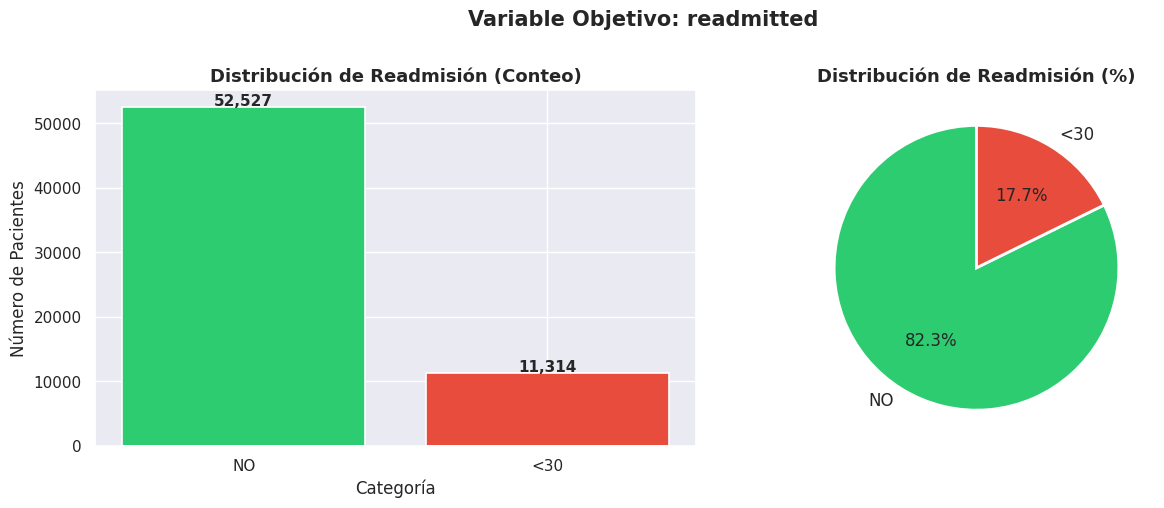


⚠️  DESBALANCE: La clase '<30' (alto riesgo) representa solo el 17.7% de los datos.
   Esto deberá tratarse con SMOTE o undersampling en la fase de modelado.


In [30]:
counts = df['readmitted'].value_counts()
pct    = df['readmitted'].value_counts(normalize=True) * 100

print("📊 DISTRIBUCIÓN DE READMITTED:\n")
for cat in counts.index:
    bar = '█' * int(pct[cat] / 2)
    print(f"  {cat:>4s}: {counts[cat]:>6,} pacientes  ({pct[cat]:5.1f}%)  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- FILTRADO DE CATEGORÍA ---
# Eliminamos '>30' para convertirlo en un problema de clasificación binaria
df = df[df['readmitted'] != '>30'].copy()

# Verificamos la nueva distribución
counts_new = df['readmitted'].value_counts()
print(f"✅ Categoría '>30' eliminada.")
print(f"Nueva distribución:\n{counts_new}")

# Barras
colores = [PALETTE_OBJ[c] for c in counts.index]
bars = axes[0].bar(counts.index, counts.values, color=colores, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribución de Readmisión (Conteo)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Categoría'); axes[0].set_ylabel('Número de Pacientes')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+200, f'{v:,}', ha='center', fontweight='bold')

# Pastel
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colores, startangle=90, textprops={'fontsize':12},
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Distribución de Readmisión (%)', fontsize=13, fontweight='bold')

plt.suptitle('Variable Objetivo: readmitted', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print(f"\n⚠️  DESBALANCE: La clase '<30' (alto riesgo) representa solo el {pct.get('<30',0):.1f}% de los datos.")
print("   Esto deberá tratarse con SMOTE o undersampling en la fase de modelado.")
# Actualiza esta línea en la siguiente celda:
df['readmitted_enc'] = df['readmitted'].map({'NO': 0, '<30': 1})

In [8]:

print(df['readmitted_enc'].value_counts())

readmitted_enc
0    52527
1    11314
Name: count, dtype: int64


---
## 6. Análisis Univariado — Variables Numéricas

**Regla del estándar mínimo del EDA:**
- Si la distribución es **simétrica** (|skewness| < 0.5) → reportar **Media ± Desviación Estándar**
- Si la distribución es **asimétrica o con outliers** (|skewness| ≥ 0.5) → reportar **Mediana + Rango IQR**

Para cada variable se presenta un **histograma** (forma de la distribución) y un **boxplot** (detección de outliers).


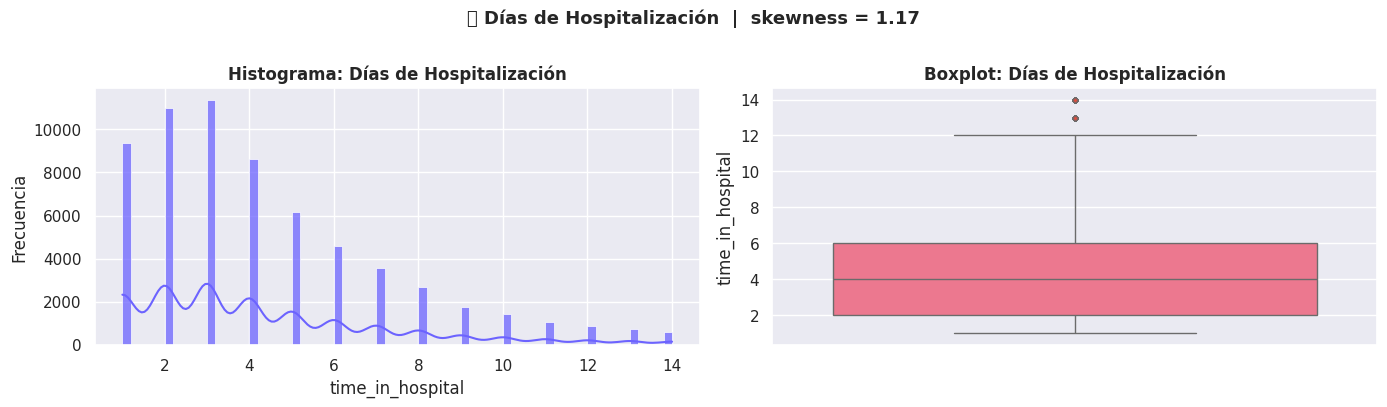

  ⚠️  Distribución ASIMÉTRICA hacia la derecha (positivo)
     Mediana = 4.0  |  IQR = [2.0 – 6.0]  |  Outliers detectados
------------------------------------------------------------


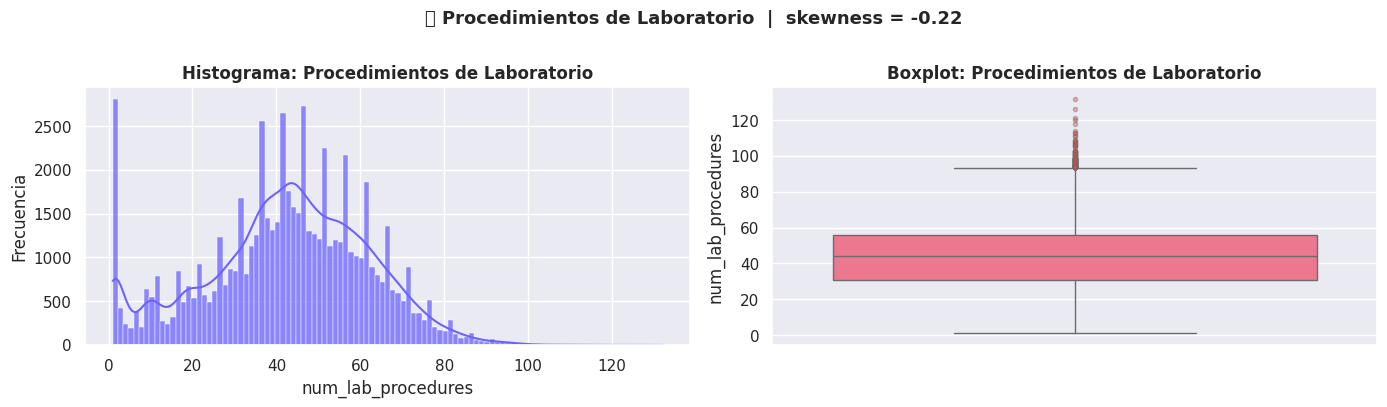

  ✅ Distribución SIMÉTRICA  →  Media = 42.39  |  Desv. Est. = 19.62
------------------------------------------------------------


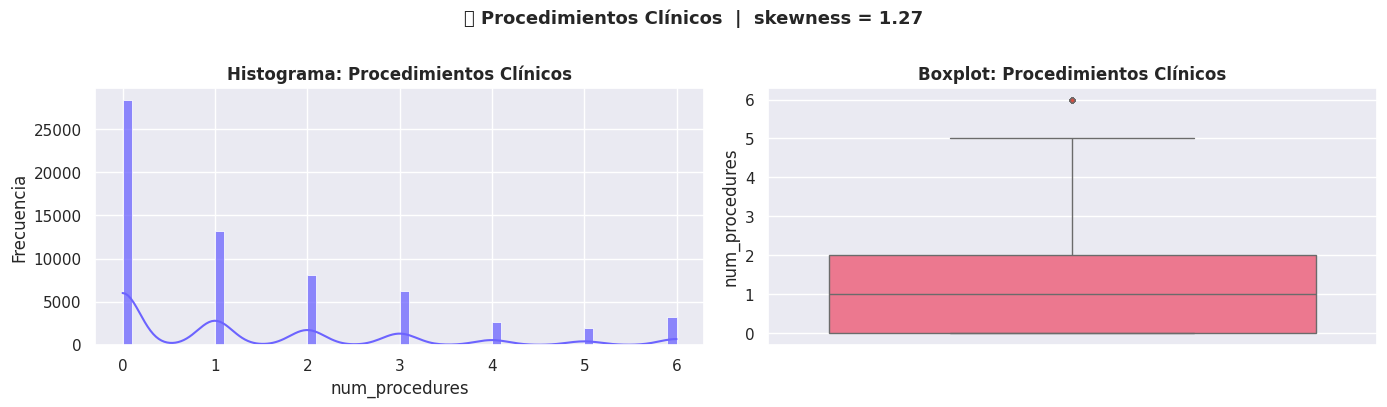

  ⚠️  Distribución ASIMÉTRICA hacia la derecha (positivo)
     Mediana = 1.0  |  IQR = [0.0 – 2.0]  |  Outliers detectados
------------------------------------------------------------


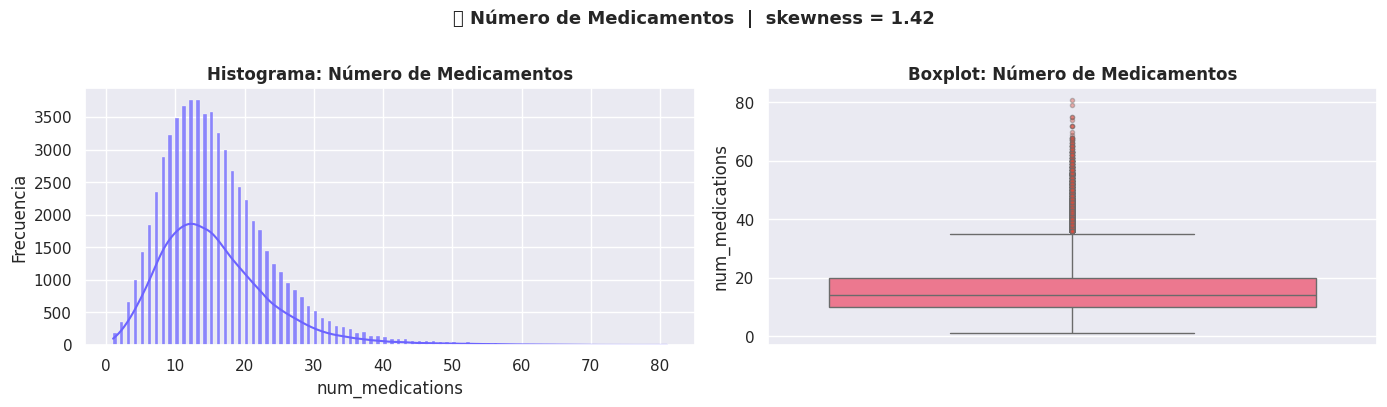

  ⚠️  Distribución ASIMÉTRICA hacia la derecha (positivo)
     Mediana = 14.0  |  IQR = [10.0 – 20.0]  |  Outliers detectados
------------------------------------------------------------


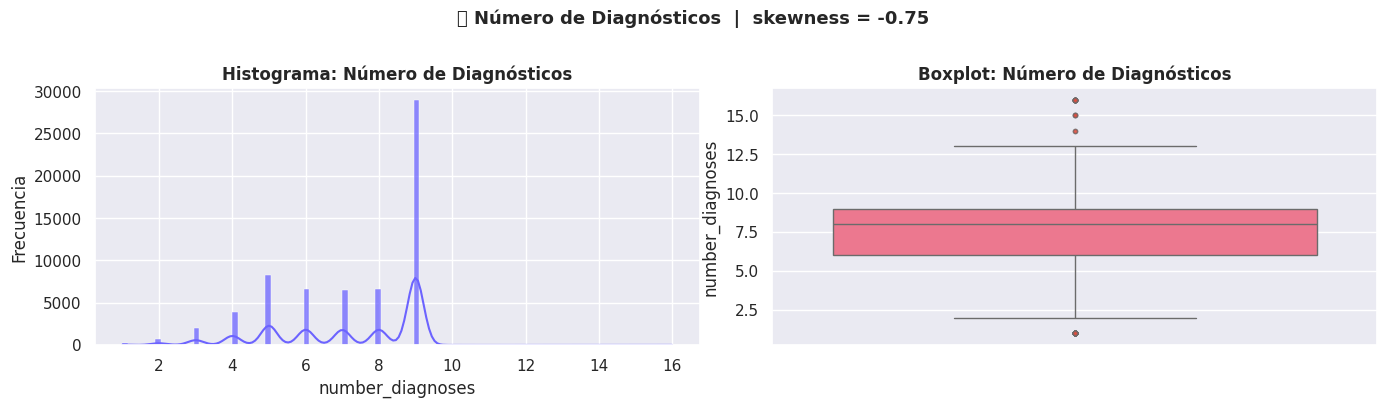

  ⚠️  Distribución ASIMÉTRICA hacia la izquierda (negativo)
     Mediana = 8.0  |  IQR = [6.0 – 9.0]  |  Outliers detectados
------------------------------------------------------------


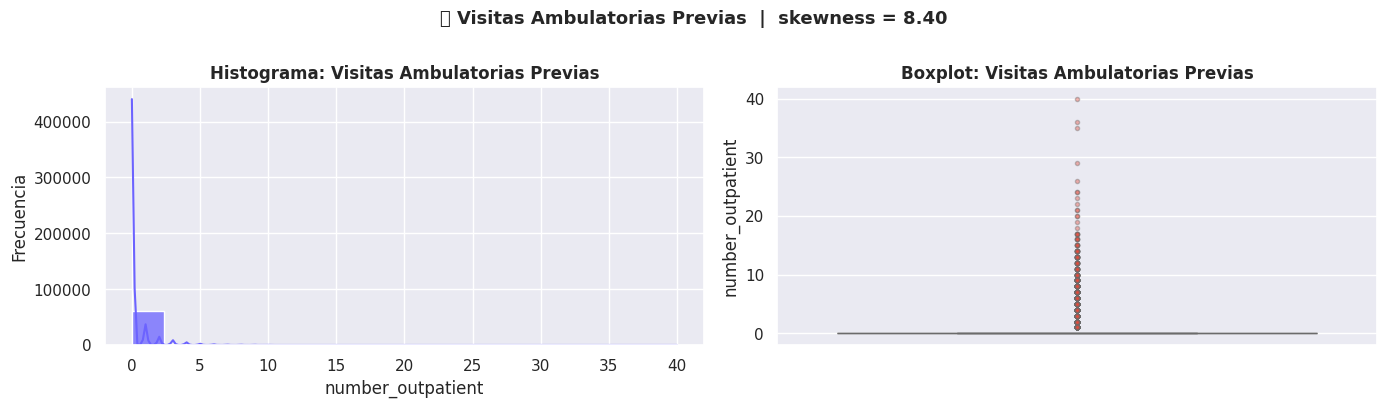

  ⚠️  Distribución ASIMÉTRICA hacia la derecha (positivo)
     Mediana = 0.0  |  IQR = [0.0 – 0.0]  |  Outliers detectados
------------------------------------------------------------


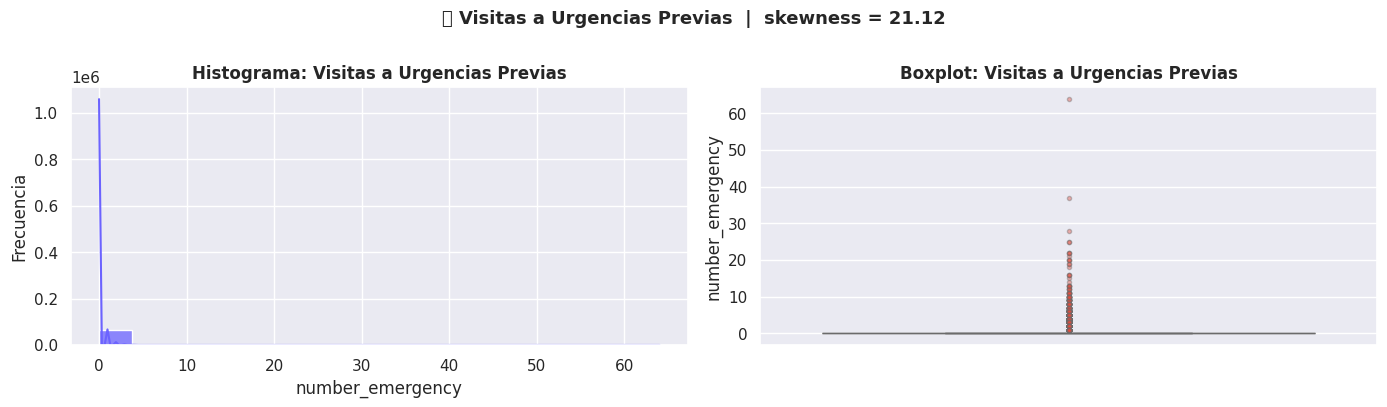

  ⚠️  Distribución ASIMÉTRICA hacia la derecha (positivo)
     Mediana = 0.0  |  IQR = [0.0 – 0.0]  |  Outliers detectados
------------------------------------------------------------


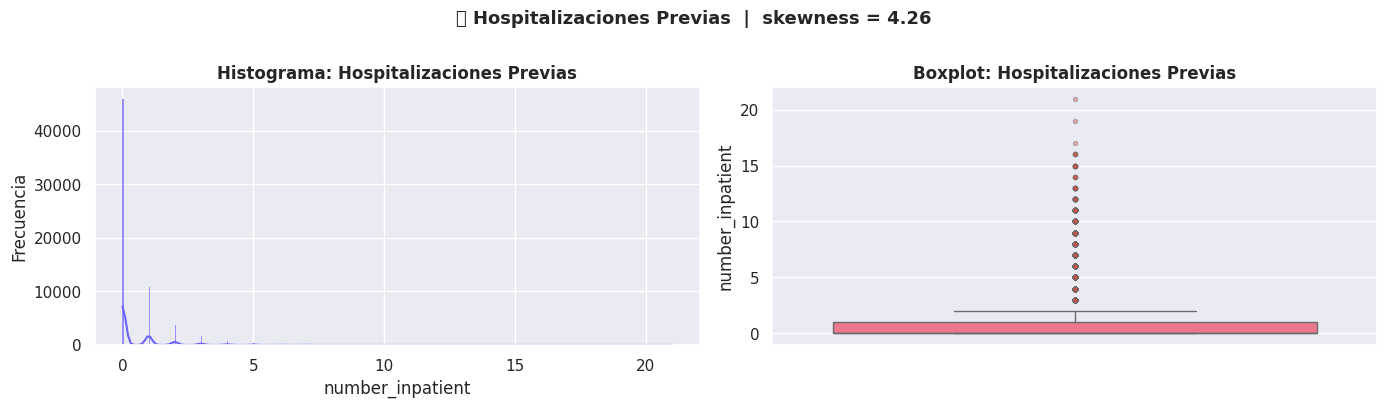

  ⚠️  Distribución ASIMÉTRICA hacia la derecha (positivo)
     Mediana = 0.0  |  IQR = [0.0 – 1.0]  |  Outliers detectados
------------------------------------------------------------


In [9]:
vars_numericas = {
    'time_in_hospital':    'Días de Hospitalización',
    'num_lab_procedures':  'Procedimientos de Laboratorio',
    'num_procedures':      'Procedimientos Clínicos',
    'num_medications':     'Número de Medicamentos',
    'number_diagnoses':    'Número de Diagnósticos',
    'number_outpatient':   'Visitas Ambulatorias Previas',
    'number_emergency':    'Visitas a Urgencias Previas',
    'number_inpatient':    'Hospitalizaciones Previas',
}

for var, titulo in vars_numericas.items():
    data = df[var].dropna()
    sk   = skew(data)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Histograma
    sns.histplot(data, kde=True, ax=axes[0], color='#6C63FF', alpha=0.75)
    axes[0].set_title(f'Histograma: {titulo}', fontweight='bold')
    axes[0].set_xlabel(var); axes[0].set_ylabel('Frecuencia')

    # Boxplot
    sns.boxplot(y=data, ax=axes[1], color='#FF6584',
                flierprops={'marker':'o','markersize':3,'alpha':0.4,'markerfacecolor':'#e74c3c'})
    axes[1].set_title(f'Boxplot: {titulo}', fontweight='bold')
    axes[1].set_ylabel(var)

    plt.suptitle(f'📊 {titulo}  |  skewness = {sk:.2f}', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()

    # Estadístico correcto según la forma
    if abs(sk) < 0.5:
        print(f"  ✅ Distribución SIMÉTRICA  →  Media = {data.mean():.2f}  |  Desv. Est. = {data.std():.2f}")
    else:
        q1, q3 = data.quantile(0.25), data.quantile(0.75)
        tipo = "derecha (positivo)" if sk > 0 else "izquierda (negativo)"
        print(f"  ⚠️  Distribución ASIMÉTRICA hacia la {tipo}")
        print(f"     Mediana = {data.median():.1f}  |  IQR = [{q1:.1f} – {q3:.1f}]  |  Outliers detectados")
    print("-" * 60)


---
## 7. Análisis Univariado — Variables Categóricas

Para variables categóricas se reporta la **frecuencia absoluta (conteo)** y el **porcentaje (%)** de cada categoría, acompañados de un gráfico de barras o pastel según el número de categorías.



📊 RAZA DEL PACIENTE:
   Caucasian                               : 47,122 ( 73.8%)
   AfricanAmerican                         : 12,154 ( 19.0%)
   NaN/Faltante                            :  1,696 (  2.7%)
   Hispanic                                :  1,376 (  2.2%)
   Other                                   :  1,026 (  1.6%)
   Asian                                   :    467 (  0.7%)


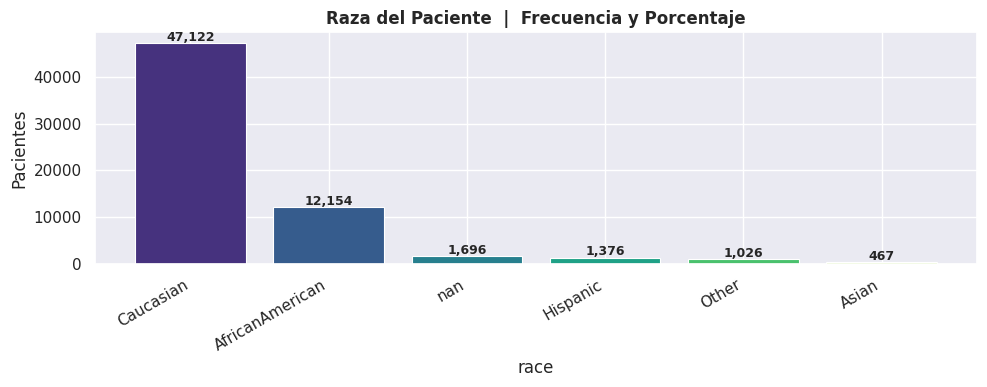

------------------------------------------------------------

📊 GÉNERO:
   Female                                  : 33,961 ( 53.2%)
   Male                                    : 29,877 ( 46.8%)
   Unknown/Invalid                         :      3 (  0.0%)


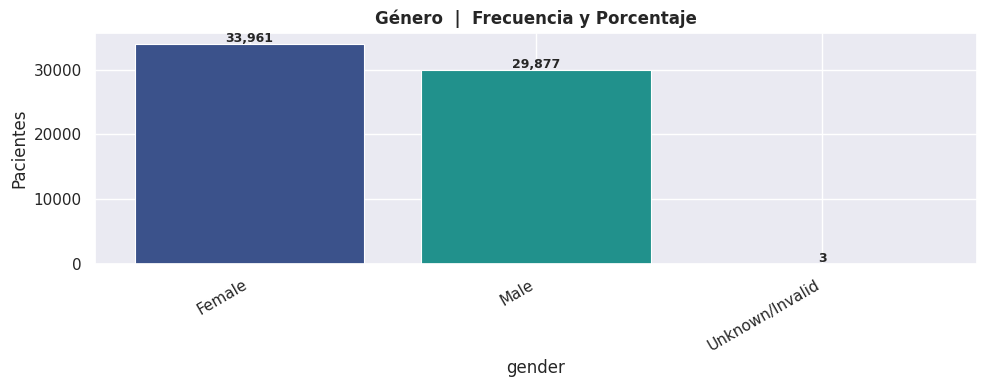

------------------------------------------------------------

📊 GRUPO DE EDAD:
   [70-80)                                 : 15,868 ( 24.9%)
   [60-70)                                 : 14,171 ( 22.2%)
   [50-60)                                 : 11,149 ( 17.5%)
   [80-90)                                 : 10,223 ( 16.0%)
   [40-50)                                 :  6,332 (  9.9%)
   [30-40)                                 :  2,577 (  4.0%)
   [90-100)                                :  1,782 (  2.8%)
   [20-30)                                 :  1,139 (  1.8%)
   [10-20)                                 :    466 (  0.7%)
   [0-10)                                  :    134 (  0.2%)


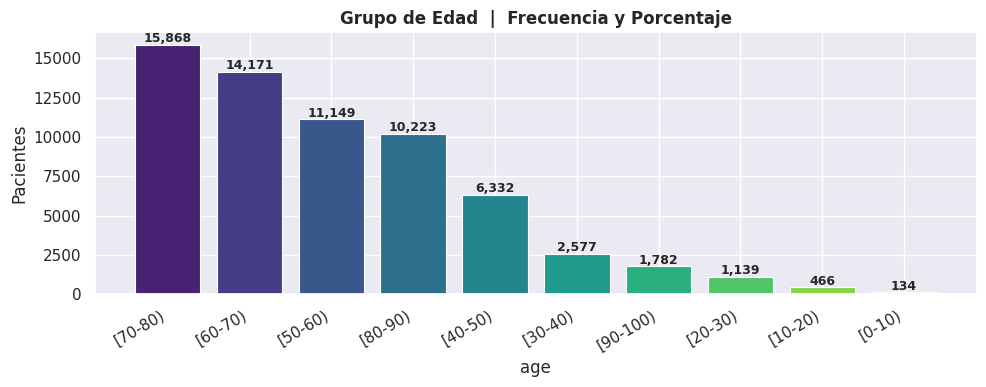

------------------------------------------------------------

📊 TIPO DE ADMISIÓN:
   Emergency                               : 33,096 ( 51.8%)
   Elective                                : 12,927 ( 20.2%)
   Urgent                                  : 11,684 ( 18.3%)
   NaN/Faltante                            :  2,976 (  4.7%)
   Not Available                           :  2,896 (  4.5%)
   Not Mapped                              :    236 (  0.4%)
   Trauma Center                           :     18 (  0.0%)
   Newborn                                 :      8 (  0.0%)


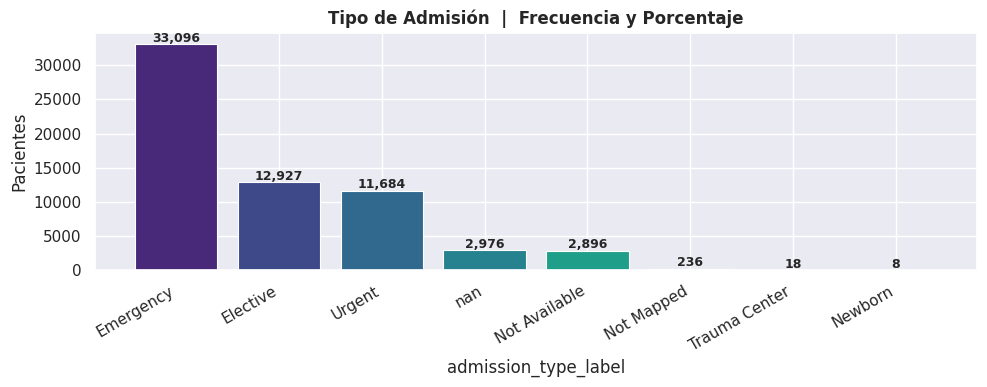

------------------------------------------------------------

📊 TIPO DE ALTA HOSPITALARIA:
   Home                                    : 38,717 ( 60.6%)
   SNF                                     :  9,038 ( 14.2%)
   Home+Health Service                     :  7,540 ( 11.8%)
   NaN/Faltante                            :  2,773 (  4.3%)
   Rehab Facility                          :  1,474 (  2.3%)
   Short-term Hospital                     :  1,460 (  2.3%)
   Other Inpatient                         :    834 (  1.3%)
   Not Mapped                              :    613 (  1.0%)
   ICF                                     :    537 (  0.8%)
   Left AMA                                :    402 (  0.6%)


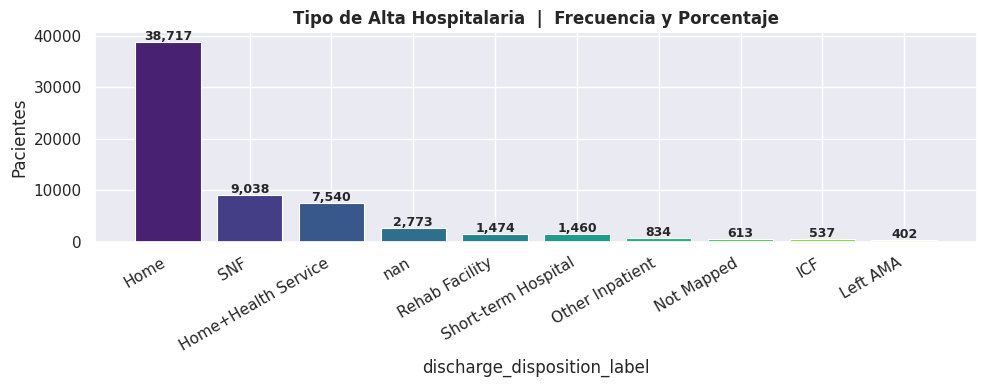

------------------------------------------------------------

📊 FUENTE DE ADMISIÓN:
   Emergency Room                          : 34,218 ( 53.6%)
   Physician Referral                      : 19,536 ( 30.6%)
   NaN/Faltante                            :  4,212 (  6.6%)
   Transfer Hospital                       :  2,446 (  3.8%)
   Transfer Other                          :  1,841 (  2.9%)
   Clinic Referral                         :    771 (  1.2%)
   Transfer SNF                            :    570 (  0.9%)
   HMO Referral                            :    127 (  0.2%)
   Not Available                           :    109 (  0.2%)
   Court/Law                               :     11 (  0.0%)


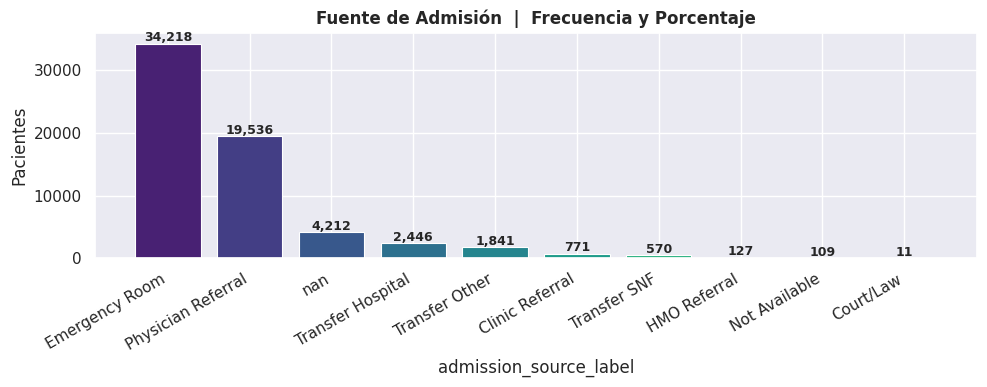

------------------------------------------------------------
⚠️  Columna 'A1Cresult' no encontrada, se omite.

📊 DOSIS DE INSULINA:
   No                                      : 30,443 ( 47.7%)
   Steady                                  : 19,601 ( 30.7%)
   Down                                    :  7,164 ( 11.2%)
   Up                                      :  6,633 ( 10.4%)


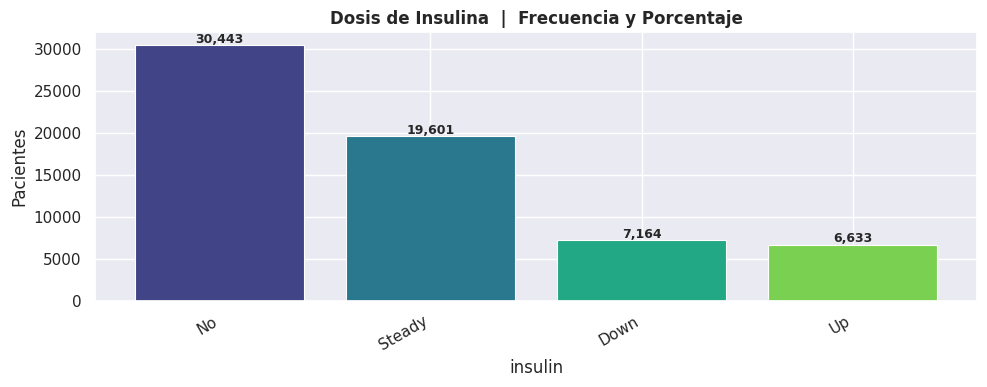

------------------------------------------------------------

📊 CAMBIO DE MEDICAMENTO:
   No                                      : 34,970 ( 54.8%)
   Ch                                      : 28,871 ( 45.2%)


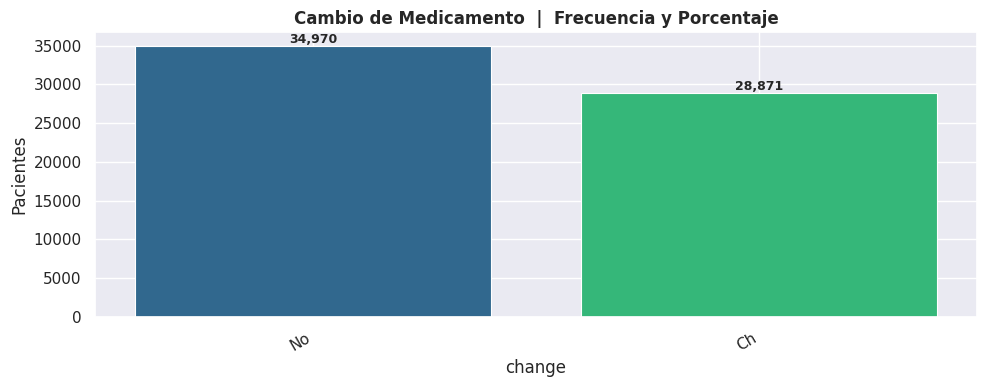

------------------------------------------------------------

📊 USO DE MEDICACIÓN PARA DIABETES:
   Yes                                     : 48,436 ( 75.9%)
   No                                      : 15,405 ( 24.1%)


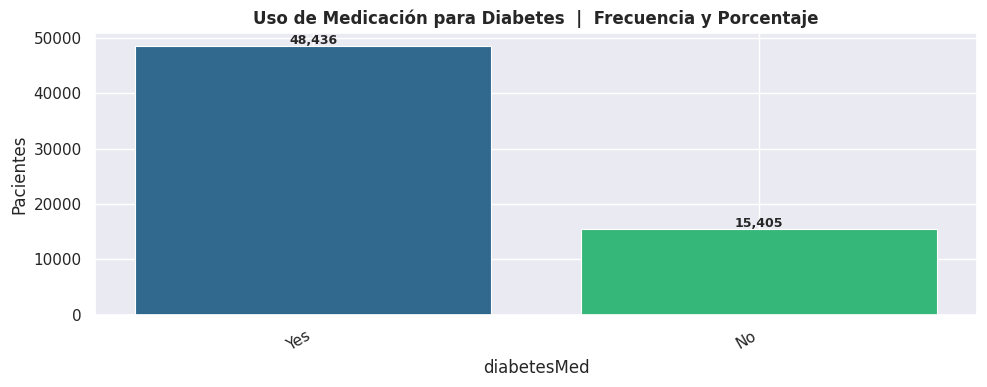

------------------------------------------------------------


In [10]:
vars_categoricas = {
    'race':                       'Raza del Paciente',
    'gender':                     'Género',
    'age':                        'Grupo de Edad',
    'admission_type_label':       'Tipo de Admisión',
    'discharge_disposition_label':'Tipo de Alta Hospitalaria',
    'admission_source_label':     'Fuente de Admisión',
    'A1Cresult':                  'Resultado Hemoglobina A1C',
    'insulin':                    'Dosis de Insulina',
    'change':                     'Cambio de Medicamento',
    'diabetesMed':                'Uso de Medicación para Diabetes',
}

for col, titulo in vars_categoricas.items():
    if col not in df.columns:
        print(f"⚠️  Columna '{col}' no encontrada, se omite.")
        continue

    counts = df[col].value_counts(dropna=False).head(10)
    pct    = df[col].value_counts(normalize=True, dropna=False) * 100

    print(f"\n📊 {titulo.upper()}:")
    for cat in counts.index:
        label = str(cat) if pd.notna(cat) else 'NaN/Faltante'
        print(f"   {label:40s}: {counts[cat]:>6,} ({pct[cat]:5.1f}%)")

    fig, ax = plt.subplots(figsize=(10, 4))
    colores_bar = sns.color_palette('viridis', len(counts))
    bars = ax.bar([str(x) for x in counts.index], counts.values,
                  color=colores_bar, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, v + counts.values.max()*0.01,
                f'{v:,}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'{titulo}  |  Frecuencia y Porcentaje', fontsize=12, fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Pacientes')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout(); plt.show()
    print("-" * 60)


---
## 8. Análisis Bivariado — Patrones e Insights con la Variable Objetivo

En esta sección cruzamos las variables más relevantes contra `readmitted` para identificar factores asociados al reingreso temprano (`<30`).


In [11]:
# Definición de grupos de variables para el análisis
vars_numericas_list = ['time_in_hospital','num_lab_procedures','num_procedures',
                       'num_medications','number_diagnoses',
                       'number_outpatient','number_emergency','number_inpatient']

vars_tratamiento = ['A1Cresult','insulin','change','diabetesMed']
vars_paciente    = ['race','gender','age']

print("✅ Grupos de variables definidos")
print(f"  Numéricas  : {vars_numericas_list}")
print(f"  Tratamiento: {vars_tratamiento}")
print(f"  Paciente   : {vars_paciente}")


✅ Grupos de variables definidos
  Numéricas  : ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'number_outpatient', 'number_emergency', 'number_inpatient']
  Tratamiento: ['A1Cresult', 'insulin', 'change', 'diabetesMed']
  Paciente   : ['race', 'gender', 'age']


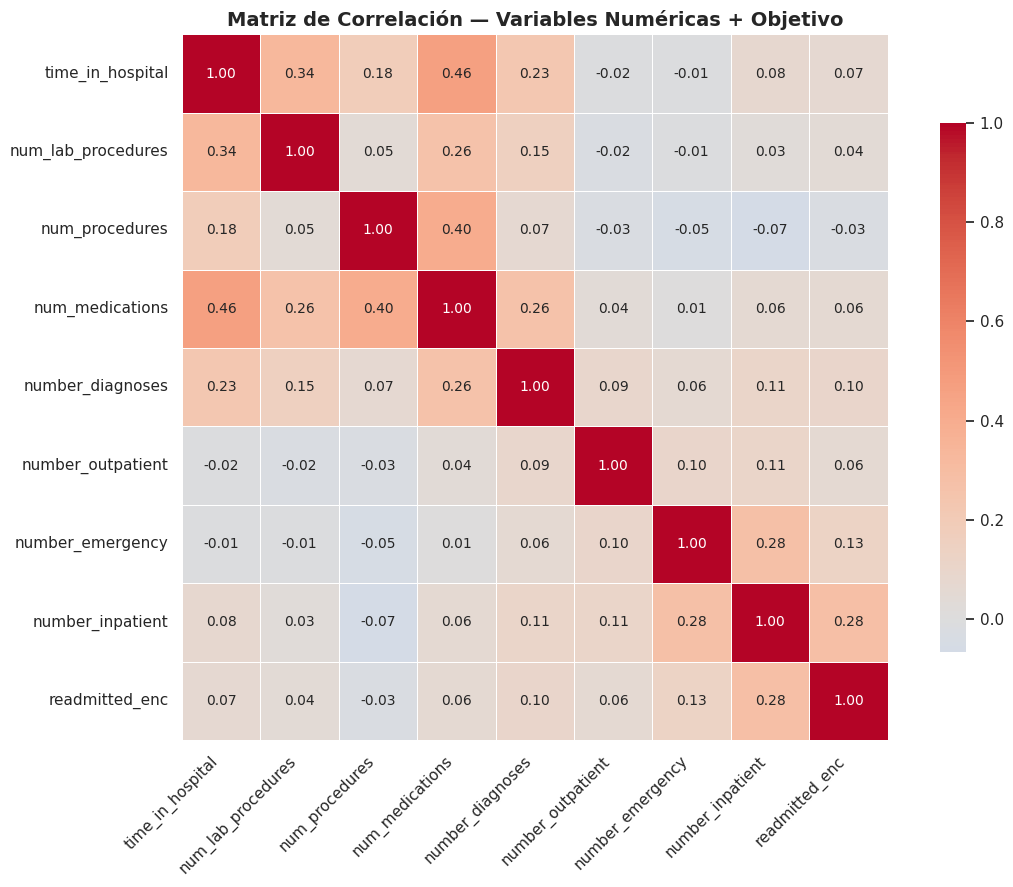


📈 TOP CORRELACIONES CON readmitted_enc:
  +0.282  →  number_inpatient
  +0.127  →  number_emergency
  +0.099  →  number_diagnoses
  +0.071  →  time_in_hospital
  +0.061  →  num_medications
  +0.060  →  number_outpatient
  +0.043  →  num_lab_procedures
  -0.027  →  num_procedures


In [12]:
# Codificar readmitted para correlación
df['readmitted_enc'] = df['readmitted'].map({'NO': 0, '<30': 1})

numeric_df  = df[vars_numericas_list + ['readmitted_enc']]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink':0.75},
            annot_kws={'size':10})
plt.title('Matriz de Correlación — Variables Numéricas + Objetivo', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

# Top correlaciones con readmitted
print("\n📈 TOP CORRELACIONES CON readmitted_enc:")
corr_target = corr_matrix['readmitted_enc'].drop('readmitted_enc').abs().sort_values(ascending=False)
for var, val in corr_target.items():
    signo = '+' if corr_matrix.loc[var,'readmitted_enc'] >= 0 else '-'
    print(f"  {signo}{val:.3f}  →  {var}")


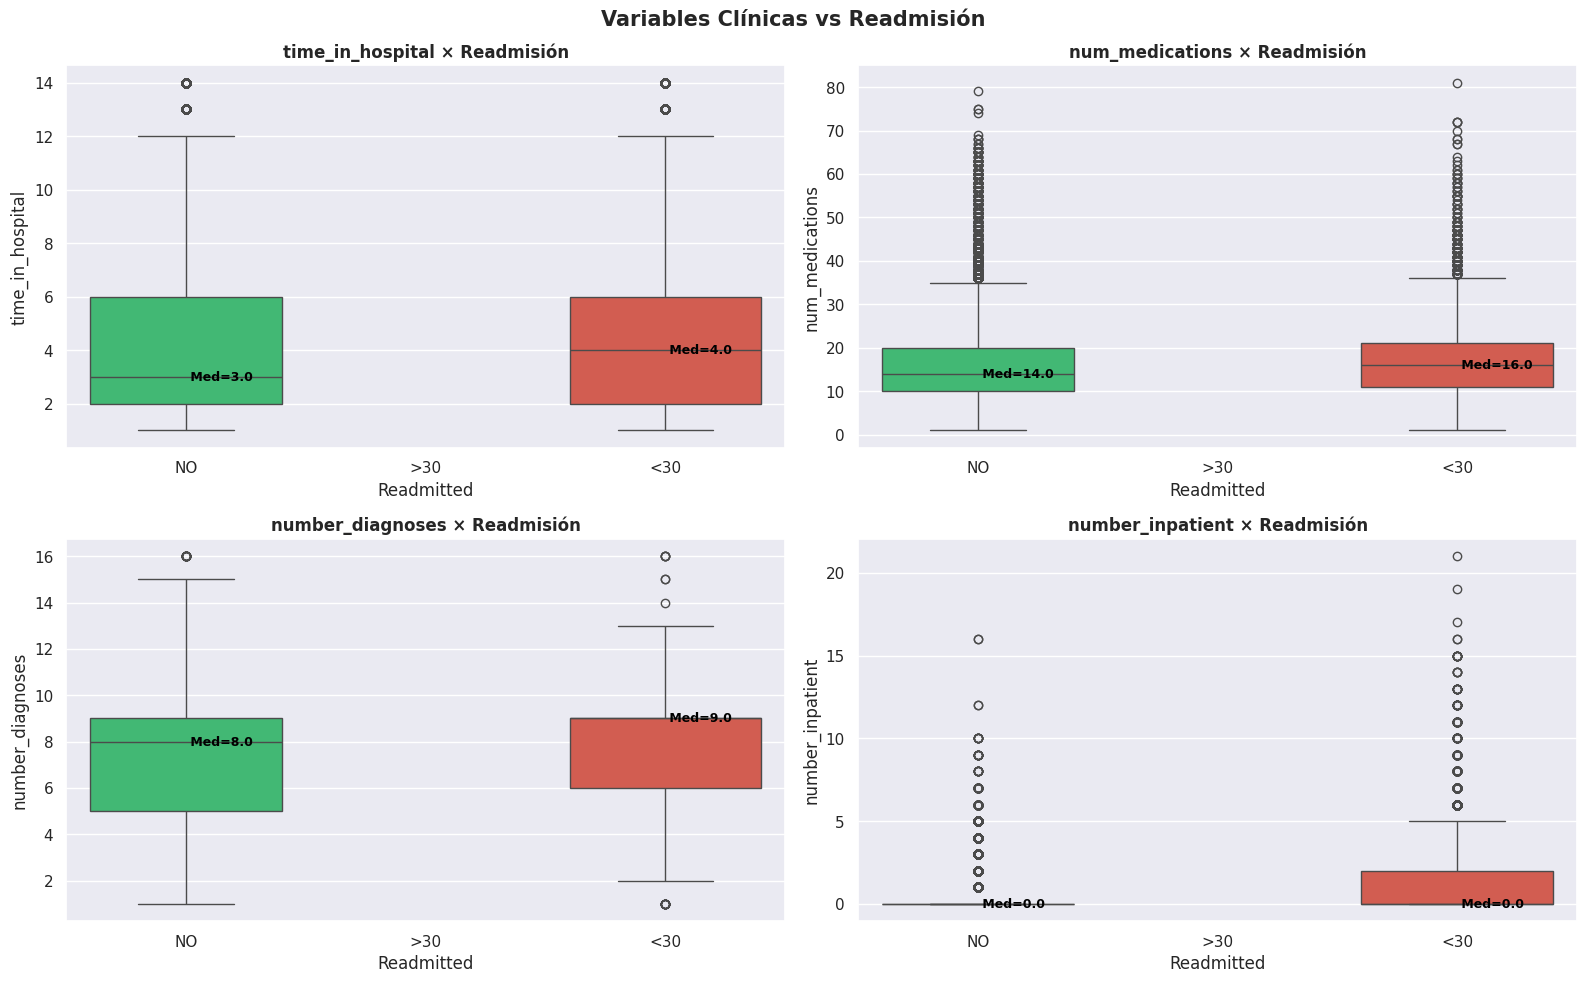

In [13]:
# ── Boxplot: variables clínicas × readmitted ────────────────────────────
vars_cruce = ['time_in_hospital','num_medications','number_diagnoses','number_inpatient']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

orden = ['NO', '>30', '<30']
colores_cruce = [PALETTE_OBJ[c] for c in orden]

for i, var in enumerate(vars_cruce):
    sns.boxplot(data=df, x='readmitted', y=var, order=orden,
                palette=PALETTE_OBJ, ax=axes[i])
    axes[i].set_title(f'{var} × Readmisión', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Readmitted')
    axes[i].set_ylabel(var)

    # Mediana por grupo
    medians = df.groupby('readmitted')[var].median()
    for j, cat in enumerate(orden):
        if cat in medians:
            axes[i].text(j, medians[cat], f' Med={medians[cat]:.1f}',
                         va='center', fontsize=9, color='black', fontweight='bold')

plt.suptitle('Variables Clínicas vs Readmisión', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


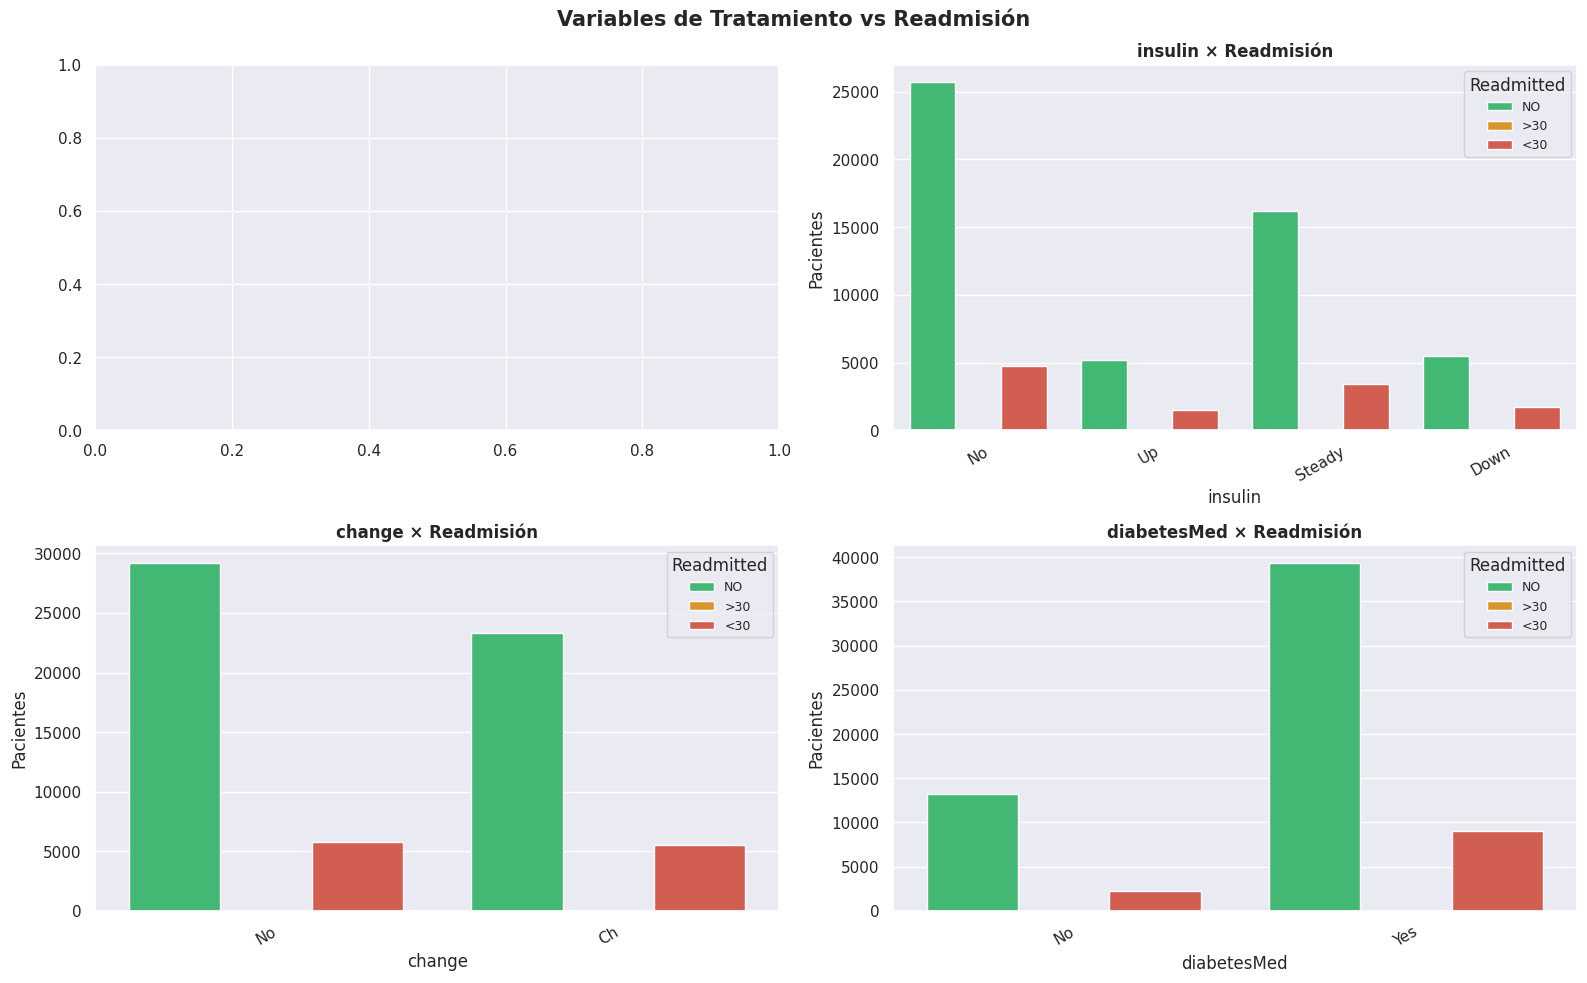

In [14]:
# ── Countplot: variables de tratamiento × readmitted ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(vars_tratamiento):
    if var not in df.columns:
        continue
    data_var = df[var].astype(str).str.strip().replace('nan','Faltante')
    temp = df.copy(); temp[var] = data_var

    sns.countplot(data=temp, x=var, hue='readmitted',
                  hue_order=['NO','>30','<30'], palette=PALETTE_OBJ,
                  ax=axes[i], edgecolor='white')
    axes[i].set_title(f'{var} × Readmisión', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(var); axes[i].set_ylabel('Pacientes')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Readmitted', fontsize=9)

plt.suptitle('Variables de Tratamiento vs Readmisión', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


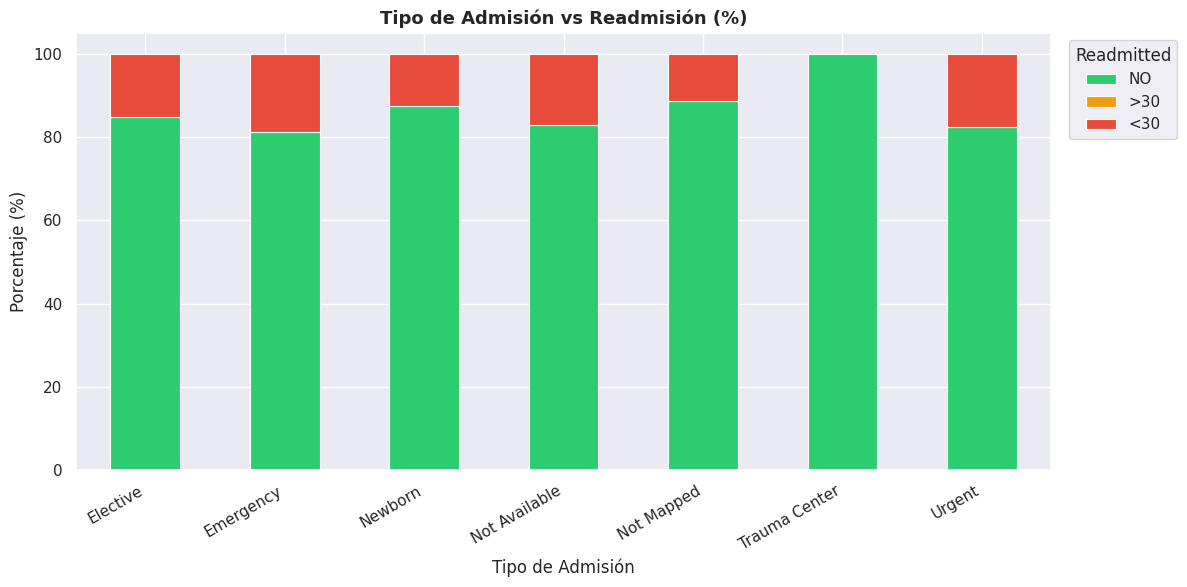


📋 Tabla de contingencia (%):
readmitted               NO  >30   <30
admission_type_label                  
Elective               84.9    0  15.1
Emergency              81.3    0  18.7
Newborn                87.5    0  12.5
Not Available          83.0    0  17.0
Not Mapped             88.6    0  11.4
Trauma Center         100.0    0   0.0
Urgent                 82.4    0  17.6


In [15]:
# ── Stacked bar: Tipo de Admisión × Readmisión ──────────────────────────
if 'admission_type_label' in df.columns:
    ct = pd.crosstab(df['admission_type_label'], df['readmitted'])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    # Reordenar columnas
    for col in ['NO','>30','<30']:
        if col not in ct_pct.columns:
            ct_pct[col] = 0
    ct_pct = ct_pct[['NO','>30','<30']]

    ax = ct_pct.plot(kind='bar', stacked=True, figsize=(12, 6),
                     color=[PALETTE_OBJ['NO'], PALETTE_OBJ['>30'], PALETTE_OBJ['<30']],
                     edgecolor='white', linewidth=0.8)
    plt.title('Tipo de Admisión vs Readmisión (%)', fontsize=13, fontweight='bold')
    plt.xlabel('Tipo de Admisión'); plt.ylabel('Porcentaje (%)')
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Readmitted', bbox_to_anchor=(1.01,1))
    plt.tight_layout(); plt.show()

    print("\n📋 Tabla de contingencia (%):")
    print(ct_pct.round(1).to_string())


---
## 9. Conclusiones

A partir del Análisis Exploratorio de Datos realizado, se identificaron los siguientes hallazgos principales:

### 🔍 Hallazgos Clave

**Variable Objetivo:**
- La clase `<30` (reingreso temprano) es minoría, lo que confirma un problema de **desbalance de clases** que deberá tratarse en el modelado.

**Variables Numéricas:**
- La mayoría presentan distribuciones **asimétricas hacia la derecha**, por lo que se reportó Mediana e IQR como estadísticos de tendencia central.
- `number_inpatient` (hospitalizaciones previas) muestra la mayor correlación con la readmisión temprana: pacientes con más ingresos previos tienen mayor riesgo.
- `num_medications` y `time_in_hospital` también se asocian positivamente con el reingreso.

**Variables Categóricas:**
- Los pacientes admitidos por **Emergency** presentan mayor tasa de reingreso temprano que los electivos.
- Los pacientes con dosis de insulina (`Up` o `Down`) muestran mayor proporción de reingresos `<30`.
- La mayoría de los pacientes son **Caucásicos** y de **género femenino**, lo cual refleja la demografía del dataset original.

**Calidad de Datos:**
- Se eliminaron las columnas `weight`, `payer_code` y `medical_specialty` por tener más del 50% de valores faltantes.
- Se filtraron ~3,500 registros de pacientes fallecidos o en hospicios que no podían ser readmitidos.


---
## 10. Próximos Pasos — Plan de Preprocesamiento y Modelado

### Preprocesamiento
1. **Imputación de nulos restantes:** Usar la moda para variables categóricas con baja tasa de nulos (e.g., `race`).
2. **Codificación de variables categóricas:**
   - Variables binarias (`change`, `diabetesMed`) → Label Encoding
   - Variables ordinales (`age`, `insulin`) → Ordinal Encoding
   - Variables nominales (`race`, `admission_type_label`) → One-Hot Encoding
3. **Tratamiento de outliers:** Aplicar Winsorización en variables como `number_outpatient` y `number_emergency`.
4. **Balanceo de clases:** Aplicar **SMOTE** (Synthetic Minority Oversampling Technique) sobre la clase `<30`.
5. **Normalización:** Escalar variables numéricas con `StandardScaler` o `MinMaxScaler`.

### Modelos Propuestos
| Modelo | Justificación |
|---|---|
| **Random Forest** | Robusto ante outliers, maneja variables mixtas, buena interpretabilidad |
| **XGBoost** | Excelente con clases desbalanceadas y alta dimensionalidad |
| **Logistic Regression** | Línea base interpretable para comparación |

### Métricas de Evaluación
- **F1-Score (macro):** Por el desbalance de clases
- **AUC-ROC:** Para evaluar la discriminación del modelo
- **Recall de clase `<30`:** Minimizar falsos negativos (no identificar pacientes de alto riesgo)

---
*Notebook desarrollado por el grupo de proyecto — IA1 2026-1 | UIS*


---
---
# 📌 CORTE 2: Modelado y Optimización de Hiperparámetros

**Objetivo**: Entrenar y optimizar 4 modelos (Gaussian NB, Decision Tree, Random Forest, SVM) con búsqueda de hiperparámetros para predecir readmisión temprana (`<30`).

**Conexión con el EDA**: En el análisis anterior confirmamos que:
- La clase `<30` es minoría (~11%) → necesitamos SMOTE y `class_weight`
- `number_inpatient` es el predictor más correlacionado con readmisión
- Las distribuciones son asimétricas → StandardScaler para normalizar
- Pacientes de Emergency tienen mayor tasa de reingreso

In [16]:
# ── Imports adicionales para modelado ────────────────────────────────────
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      RandomizedSearchCV, StratifiedKFold)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                              recall_score, precision_score, roc_auc_score,
                              ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import time

print("✅ Librerías de modelado cargadas")

✅ Librerías de modelado cargadas


---
## 11. Preparación de Features — Codificación y Selección

Codificamos las variables categóricas según su naturaleza:
- **Ordinales** (`age`, `insulin`): OrdinalEncoder que respeta el orden natural
- **Binarias** (`change`, `diabetesMed`): LabelEncoder → {0, 1}
- **Nominales** (`race`, `gender`, labels de admisión/alta): OneHotEncoder

In [20]:
# ── Codificación de variables ordinales y binarias ───────────────────────
age_map = {
    '[0-10)':0,'[10-20)':1,'[20-30)':2,'[30-40)':3,'[40-50)':4,
    '[50-60)':5,'[60-70)':6,'[70-80)':7,'[80-90)':8,'[90-100)':9
}
insulin_map = {'No':0, 'Steady':1, 'Up':2, 'Down':3}
# binary_map  = {'No':0, 'Yes':1, 'Ch':1}

change_map      = {'No':0, 'Ch':1}
binary_map      = {'No':0, 'Yes':1}



df['age_encoded']         = df['age'].map(age_map)
df['insulin_encoded']     = df['insulin'].map(insulin_map)
df['change_encoded']      = df['change'].map(change_map)
df['diabetesMed_encoded'] = df['diabetesMed'].map(binary_map)
# df['change_encoded']      = df['change'].map(binary_map)
# df['diabetesMed_encoded'] = df['diabetesMed'].map(binary_map)

# ── Definición de features ───────────────────────────────────────────────
numeric_features = [
    'time_in_hospital','num_lab_procedures','num_procedures',
    'num_medications','number_diagnoses',
    'number_outpatient','number_emergency','number_inpatient'
]
ordinal_binary_features = ['age_encoded','insulin_encoded','change_encoded','diabetesMed_encoded']
categorical_features    = ['gender','race','admission_type_label','discharge_disposition_label']
all_features = numeric_features + ordinal_binary_features + categorical_features
target = 'readmitted_enc'

# Validar
missing = [f for f in all_features if f not in df.columns]
if missing:
    print(f"⚠️  Features faltantes: {missing}")
else:
    print(f"✅ {len(all_features)} features validadas")
    print(f"   Numéricas: {len(numeric_features)} | Ordinales/Binarias: {len(ordinal_binary_features)} | Categóricas: {len(categorical_features)}")

# Imputar nulos restantes
for col in numeric_features + ordinal_binary_features:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
for col in categorical_features:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f"✅ Nulos imputados (mediana para numéricas, moda para categóricas)")

✅ 16 features validadas
   Numéricas: 8 | Ordinales/Binarias: 4 | Categóricas: 4
✅ Nulos imputados (mediana para numéricas, moda para categóricas)


---
## 12. Split Train/Test y Preprocessing

**Orden correcto**: Split PRIMERO con datos crudos, luego fit del scaler SOLO en train.
Esto garantiza que el StandardScaler no aprenda media/varianza del test set.

In [21]:
# ── Preparar X e y ───────────────────────────────────────────────────────
X = df[all_features].copy()
y = df[target].copy()

# 1. SPLIT PRIMERO (datos crudos)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 2. ColumnTransformer: fit SOLO en train
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric_scaler', StandardScaler(), numeric_features),
        ('ordinal_binary_identity', 'passthrough', ordinal_binary_features),
        ('nominal_onehot', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

preprocessor.fit(X_train_raw)                    # ← fit SOLO en train
X_train = preprocessor.transform(X_train_raw)    # transform train
X_test  = preprocessor.transform(X_test_raw)     # transform test (sin fit)

# Manejar NaN residuales
X_train = np.nan_to_num(X_train, nan=0.0)
X_test  = np.nan_to_num(X_test, nan=0.0)

# Reconstruir nombres de features
ohe_names = list(preprocessor.named_transformers_['nominal_onehot']
                 .get_feature_names_out(categorical_features))
feature_names = numeric_features + ordinal_binary_features + ohe_names

print(f"✅ Split 75/25 estratificado")
print(f"   Train: {X_train.shape[0]:,} × {X_train.shape[1]} features")
print(f"   Test:  {X_test.shape[0]:,} × {X_test.shape[1]} features")
print(f"\n📊 Distribución en TRAIN:")
print((y_train.value_counts() / len(y_train) * 100).round(1).to_dict())
print(f"\n📊 Distribución en TEST:")
print((y_test.value_counts() / len(y_test) * 100).round(1).to_dict())

✅ Split 75/25 estratificado
   Train: 47,880 × 41 features
   Test:  15,961 × 41 features

📊 Distribución en TRAIN:
{0: 82.3, 1: 17.7}

📊 Distribución en TEST:
{0: 82.3, 1: 17.7}


---
## 13. Aplicar SMOTE en Conjunto de Entrenamiento

SMOTE genera muestras sintéticas de la clase minoritaria `<30` usando interpolación entre vecinos cercanos. Se aplica **solo al conjunto de entrenamiento** para evitar data leakage.

In [ ]:
smote = SMOTE(sampling_strategy='minority', random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"✅ SMOTE aplicado (sampling_strategy=0.3)")
print(f"\n📊 ANTES de SMOTE ({len(X_train):,} muestras):")
for cls, cnt in y_train.value_counts().items():
    print(f"   {str(cls):>4s}: {cnt:>6,} ({cnt/len(y_train)*100:.1f}%)")

print(f"\n📊 DESPUÉS de SMOTE ({len(X_train_balanced):,} muestras):")
from collections import Counter
for cls, cnt in sorted(Counter(y_train_balanced).items()):
    print(f"   {str(cls):>4s}: {cnt:>6,} ({cnt/len(y_train_balanced)*100:.1f}%)")

✅ SMOTE aplicado (sampling_strategy=0.3)

📊 ANTES de SMOTE (47,880 muestras):
      0: 39,395 (82.3%)
      1:  8,485 (17.7%)

📊 DESPUÉS de SMOTE (78,790 muestras):
      0: 39,395 (50.0%)
      1: 39,395 (50.0%)


---
## 14. Configuración de Métricas y Validación Cruzada

**Métrica de optimización**: F1-macro — promedia F1 de las 3 clases con igual peso.
**Métrica clínica crítica**: Recall de `<30` — minimizar falsos negativos.
**Validación**: StratifiedKFold(5) dentro del GridSearch.

In [22]:
scoring = {
    'f1_macro': 'f1_macro',
    'recall_macro': 'recall_macro',
    'precision_macro': 'precision_macro',
    'accuracy': 'accuracy'
}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("✅ Configuración de evaluación:")
print("   Scorer primario: F1-macro")
print("   Validación: StratifiedKFold(5)")
print("   Métricas secundarias: Recall-macro, Precision-macro, Accuracy")

✅ Configuración de evaluación:
   Scorer primario: F1-macro
   Validación: StratifiedKFold(5)
   Métricas secundarias: Recall-macro, Precision-macro, Accuracy


---
## 15. Modelo 1: Gaussian Naive Bayes

NB asume independencia entre features y distribución gaussiana. Como nuestras variables (medicamentos, diagnósticos, días) claramente NO son independientes, este será el modelo más débil — sirve como **línea base** para comparar.

MODELO 1: GAUSSIAN NAIVE BAYES
Fitting 5 folds for each of 5 candidates, totalling 25 fits

✅ Completado en 0.8s
   Mejor var_smoothing: 1e-05
   Accuracy: 0.7020 | F1-macro: 0.5919 | Recall <30: 0.5150 | AUC-ROC: 0.6765

📊 MATRIZ DE CONFUSIÓN - GAUSSIAN NAIVE BAYES


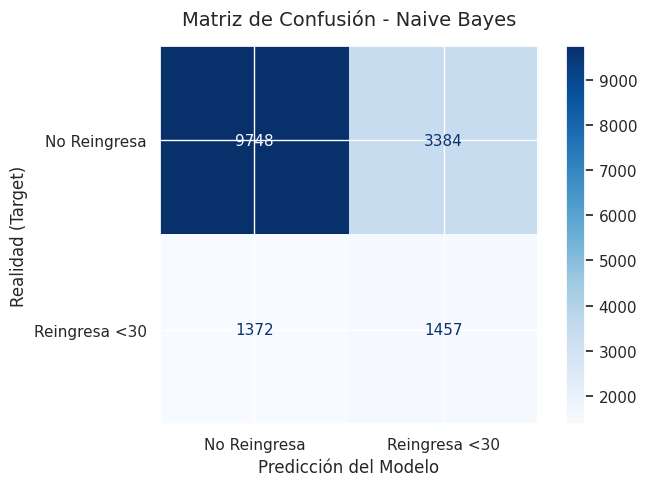


📝 Resumen de Errores Clínicos:
✅ Verdaderos Positivos (Enfermos atrapados a tiempo): 1457
✅ Verdaderos Negativos (Sanos diagnosticados bien): 9748
❌ Falsos Negativos (Graves enviados a casa): 1372
⚠️ Falsos Positivos (Sanos asustados innecesariamente): 3384


In [25]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold
# Añadimos accuracy_score, confusion_matrix, ConfusionMatrixDisplay y matplotlib
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time
import numpy as np

print("="*80)
print("MODELO 1: GAUSSIAN NAIVE BAYES")
print("="*80)

scoring = {
    'f1_macro': 'f1_macro',
    'recall_macro': 'recall_macro',
    'precision_macro': 'precision_macro',
    'accuracy': 'accuracy'
}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_nb = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}

grid_nb = GridSearchCV(
    GaussianNB(), param_grid_nb, cv=cv_strategy,
    scoring=scoring, refit='f1_macro', n_jobs=-1, verbose=1
)

start = time.time()
grid_nb.fit(X_train, y_train)
t_nb = time.time() - start

X_test_processed_nb = preprocessor.transform(X_test_raw)
X_test_processed_nb = np.nan_to_num(X_test_processed_nb, nan=0.0)
y_test_for_nb = y.loc[X_test_raw.index]

y_pred_nb = grid_nb.predict(X_test_processed_nb)

# 1. Corrección del Accuracy real
acc_nb       = accuracy_score(y_test_for_nb, y_pred_nb)
f1_nb        = f1_score(y_test_for_nb, y_pred_nb, average='macro')
recall_cls   = recall_score(y_test_for_nb, y_pred_nb, average=None, labels=[0, 1])
recall_30_nb = recall_cls[1]
prec_cls     = precision_score(y_test_for_nb, y_pred_nb, average=None, labels=[0, 1])
prec_30_nb   = prec_cls[1]
auc_nb       = roc_auc_score(y_test_for_nb, grid_nb.predict_proba(X_test_processed_nb)[:, 1])

print(f"\n✅ Completado en {t_nb:.1f}s")
print(f"   Mejor var_smoothing: {grid_nb.best_params_['var_smoothing']}")
# Imprimimos el Accuracy junto a las demás métricas
print(f"   Accuracy: {acc_nb:.4f} | F1-macro: {f1_nb:.4f} | Recall <30: {recall_30_nb:.4f} | AUC-ROC: {auc_nb:.4f}")

# ==========================================
# 2. SECCIÓN VISUAL: MATRIZ DE CONFUSIÓN
# ==========================================
print("\n" + "="*80)
print("📊 MATRIZ DE CONFUSIÓN - GAUSSIAN NAIVE BAYES")
print("="*80)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_for_nb,
    y_pred_nb,
    display_labels=['No Reingresa', 'Reingresa <30'],
    cmap='Blues',
    colorbar=True,
    ax=ax
)
plt.title('Matriz de Confusión - Naive Bayes', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad (Target)', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Resumen en texto para la Hipótesis del Informe
tn, fp, fn, tp = confusion_matrix(y_test_for_nb, y_pred_nb).ravel()
print(f"\n📝 Resumen de Errores Clínicos:")
print(f"✅ Verdaderos Positivos (Enfermos atrapados a tiempo): {tp}")
print(f"✅ Verdaderos Negativos (Sanos diagnosticados bien): {tn}")
print(f"❌ Falsos Negativos (Graves enviados a casa): {fn}")
print(f"⚠️ Falsos Positivos (Sanos asustados innecesariamente): {fp}")

---
## 16. Modelo 2: Decision Tree

Árbol de decisión con `class_weight` para penalizar errores en la clase minoritaria. Incluimos `None` en `class_weight` para demostrar empíricamente su impacto.

MODELO 2: DECISION TREE
   Combinaciones a evaluar: 320
Fitting 5 folds for each of 320 candidates, totalling 1600 fits

✅ Completado en 208.2s
   Mejores params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
   Accuracy: 0.7233 | F1-macro: 0.6141 | Recall <30: 0.5401 | AUC-ROC: 0.7054

📊 MATRIZ DE CONFUSIÓN - DECISION TREE


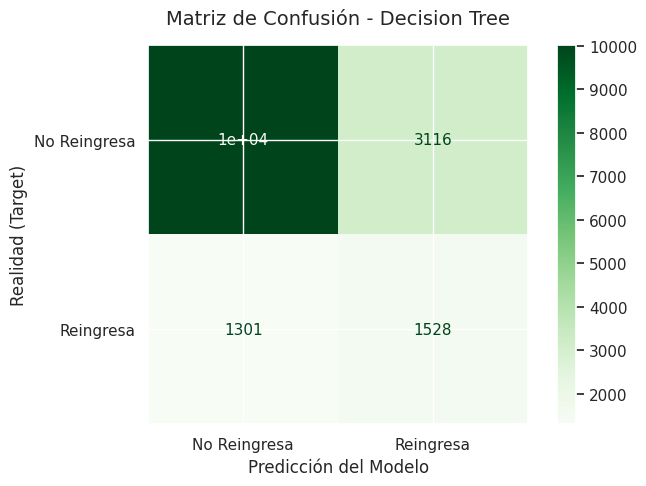


📝 Resumen de Errores Clínicos:
✅ Verdaderos Positivos (Enfermos atrapados a tiempo): 1528
✅ Verdaderos Negativos (Sanos diagnosticados bien): 10016
❌ Falsos Negativos (Graves enviados a casa): 1301
⚠️ Falsos Positivos (Sanos asustados innecesariamente): 3116


In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("="*80)
print("MODELO 2: DECISION TREE")
print("="*80)

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 4, 8, 16],
    'class_weight': ['balanced', None]
}

total_combos = 2*5*4*4*2
print(f"   Combinaciones a evaluar: {total_combos}")

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42), param_grid_dt,
    cv=cv_strategy, scoring=scoring, refit='f1_macro', n_jobs=-1, verbose=1
)

start = time.time()
grid_dt.fit(X_train, y_train)
t_dt = time.time() - start

y_pred_dt = grid_dt.predict(X_test)

# --- CORRECCIÓN DEL ACCURACY ---
acc_dt       = accuracy_score(y_test, y_pred_dt)
f1_dt        = f1_score(y_test, y_pred_dt, average='macro')
recall_cls   = recall_score(y_test, y_pred_dt, average=None, labels=[0, 1])
recall_30_dt = recall_cls[1]
prec_cls     = precision_score(y_test, y_pred_dt, average=None, labels=[0, 1])
prec_30_dt   = prec_cls[1]
auc_dt       = roc_auc_score(y_test, grid_dt.predict_proba(X_test)[:, 1])

print(f"\n✅ Completado en {t_dt:.1f}s")
print(f"   Mejores params: {grid_dt.best_params_}")
print(f"   Accuracy: {acc_dt:.4f} | F1-macro: {f1_dt:.4f} | Recall <30: {recall_30_dt:.4f} | AUC-ROC: {auc_dt:.4f}")

# ==========================================
# SECCIÓN VISUAL: MATRIZ DE CONFUSIÓN
# ==========================================
print("\n" + "="*80)
print("📊 MATRIZ DE CONFUSIÓN - DECISION TREE")
print("="*80)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    display_labels=['No Reingresa', 'Reingresa'], # Etiquetas actualizadas a binario puro
    cmap='Greens', # Le cambié el color a verde para que en el informe se distinga del modelo anterior
    colorbar=True,
    ax=ax
)
plt.title('Matriz de Confusión - Decision Tree', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad (Target)', fontsize=12)
plt.tight_layout()
plt.show()

# Resumen en texto para la Hipótesis del Informe
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt).ravel()
print(f"\n📝 Resumen de Errores Clínicos:")
print(f"✅ Verdaderos Positivos (Enfermos atrapados a tiempo): {tp}")
print(f"✅ Verdaderos Negativos (Sanos diagnosticados bien): {tn}")
print(f"❌ Falsos Negativos (Graves enviados a casa): {fn}")
print(f"⚠️ Falsos Positivos (Sanos asustados innecesariamente): {fp}")

---
## 17. Modelo 3: Random Forest (RandomizedSearchCV)

RF es el modelo con mayor potencial: robusto ante correlaciones, reduce overfitting via bagging, y soporta `balanced_subsample` que balancea por árbol individual. Usamos `RandomizedSearchCV` para optimizar velocidad.

MODELO 3: RANDOM FOREST (RandomizedSearchCV)
   Espacio total: 72 combinaciones, evaluando 60
Fitting 5 folds for each of 60 candidates, totalling 300 fits

✅ Completado en 1398.1s
   Mejores params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}
   Accuracy: 0.7800 | F1-macro: 0.6350 | Recall <30: 0.4224 | AUC-ROC: 0.7244

📊 MATRIZ DE CONFUSIÓN - RANDOM FOREST


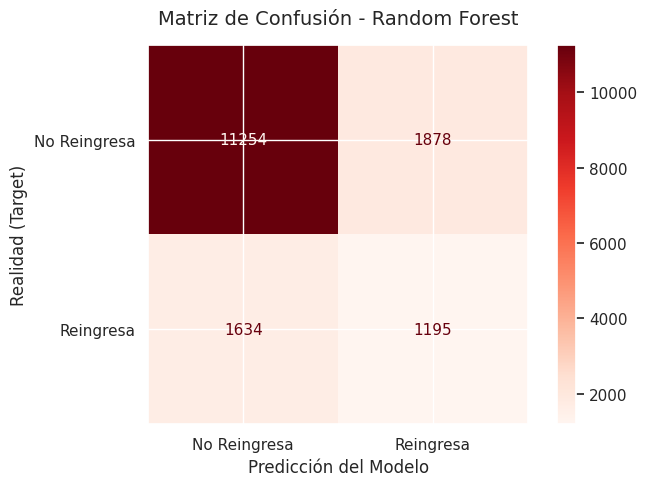


📝 Resumen de Errores Clínicos:
✅ Verdaderos Positivos (Enfermos atrapados a tiempo): 1195
✅ Verdaderos Negativos (Sanos diagnosticados bien): 11254
❌ Falsos Negativos (Graves enviados a casa): 1634
⚠️ Falsos Positivos (Sanos asustados innecesariamente): 1878


In [29]:
import time
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("="*80)
print("MODELO 3: RANDOM FOREST (RandomizedSearchCV)")
print("="*80)

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4],
    'max_features': ['sqrt'],
    'class_weight': ['balanced', 'balanced_subsample']
}

total_space = 3*3*2*2*1*2
print(f"   Espacio total: {total_space} combinaciones, evaluando 60")

grid_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist_rf, n_iter=60, cv=cv_strategy,
    scoring=scoring, refit='f1_macro',
    n_jobs=1,   # RF ya paraleliza internamente con n_jobs=-1
    random_state=42, verbose=1
)

start = time.time()
grid_rf.fit(X_train, y_train)
t_rf = time.time() - start

y_pred_rf = grid_rf.predict(X_test)

# --- CORRECCIÓN DEL ACCURACY ---
acc_rf       = accuracy_score(y_test, y_pred_rf)
f1_rf        = f1_score(y_test, y_pred_rf, average='macro')
recall_cls   = recall_score(y_test, y_pred_rf, average=None, labels=[0, 1])
recall_30_rf = recall_cls[1]
prec_cls     = precision_score(y_test, y_pred_rf, average=None, labels=[0, 1])
prec_30_rf   = prec_cls[1]
auc_rf       = roc_auc_score(y_test, grid_rf.predict_proba(X_test)[:, 1])

print(f"\n✅ Completado en {t_rf:.1f}s")
print(f"   Mejores params: {grid_rf.best_params_}")
print(f"   Accuracy: {acc_rf:.4f} | F1-macro: {f1_rf:.4f} | Recall <30: {recall_30_rf:.4f} | AUC-ROC: {auc_rf:.4f}")

# ==========================================
# SECCIÓN VISUAL: MATRIZ DE CONFUSIÓN
# ==========================================
print("\n" + "="*80)
print("📊 MATRIZ DE CONFUSIÓN - RANDOM FOREST")
print("="*80)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Reingresa', 'Reingresa'],
    cmap='Reds', # Color rojo para el Random Forest
    colorbar=True,
    values_format='d', # Desactiva la notación e+04
    ax=ax
)
plt.title('Matriz de Confusión - Random Forest', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad (Target)', fontsize=12)
plt.tight_layout()
plt.show()

# Resumen en texto
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
print(f"\n📝 Resumen de Errores Clínicos:")
print(f"✅ Verdaderos Positivos (Enfermos atrapados a tiempo): {tp}")
print(f"✅ Verdaderos Negativos (Sanos diagnosticados bien): {tn}")
print(f"❌ Falsos Negativos (Graves enviados a casa): {fn}")
print(f"⚠️ Falsos Positivos (Sanos asustados innecesariamente): {fp}")

---
## 18. Modelo 4: Support Vector Machine (RandomizedSearchCV)

SVM busca el hiperplano óptimo que maximiza el margen. Usamos `probability=True` para obtener `predict_proba` y calcular AUC-ROC. Rango de C reducido (0.1–10) porque con SMOTE valores altos sobreajustan.

MODELO 4: LINEAR SUPPORT VECTOR MACHINE (Optimizado)
Fitting 5 folds for each of 10 candidates, totalling 50 fits

✅ Completado en 22.2s
   Mejores params: {'class_weight': 'balanced', 'C': 0.1}
   Accuracy: 0.7063 | F1-macro: 0.6066 | Recall <30: 0.5726 | AUC-ROC: 0.7140

📊 MATRIZ DE CONFUSIÓN - LINEAR SVM (Optimizado)


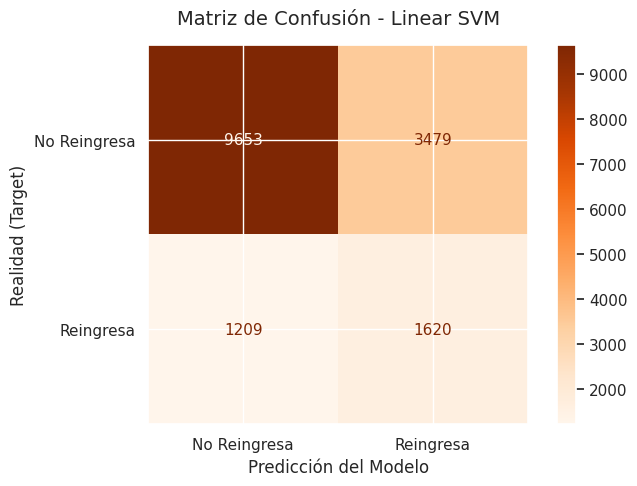


📝 Resumen de Errores Clínicos:
✅ Verdaderos Positivos (Enfermos atrapados a tiempo): 1620
✅ Verdaderos Negativos (Sanos diagnosticados bien): 9653
❌ Falsos Negativos (Graves enviados a casa): 1209
⚠️ Falsos Positivos (Sanos asustados innecesariamente): 3479


In [56]:
import time
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV
# Añadimos los imports para la matriz y el accuracy real
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("="*80)
print("MODELO 4: LINEAR SUPPORT VECTOR MACHINE (Optimizado)")
print("="*80)

# 1. Los parámetros ahora son mucho más simples
param_dist_svm = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': ['balanced', None]
}

# 2. Usamos LinearSVC. dual=False es obligatorio y súper rápido cuando tienes más pacientes que variables
grid_svm = RandomizedSearchCV(
    LinearSVC(random_state=42, dual=False),
    param_dist_svm,
    n_iter=10,
    cv=cv_strategy,
    scoring=scoring,
    refit='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

start = time.time()
# Asumiendo que ya hiciste el filtro de variables de correlación:
grid_svm.fit(X_train, y_train)
t_svm = time.time() - start

y_pred_svm = grid_svm.predict(X_test)

# --- CORRECCIÓN DEL ACCURACY ---
acc_svm       = accuracy_score(y_test, y_pred_svm)
f1_svm        = f1_score(y_test, y_pred_svm, average='macro')

recall_cls    = recall_score(y_test, y_pred_svm, average=None, labels=[0, 1])
recall_30_svm = recall_cls[1]

prec_cls      = precision_score(y_test, y_pred_svm, average=None, labels=[0, 1])
prec_30_svm   = prec_cls[1]

# 3. OJO ACÁ: Usamos decision_function en vez de predict_proba
y_scores_svm = grid_svm.decision_function(X_test)
auc_svm       = roc_auc_score(y_test, y_scores_svm)

print(f"\n✅ Completado en {t_svm:.1f}s")
print(f"   Mejores params: {grid_svm.best_params_}")
print(f"   Accuracy: {acc_svm:.4f} | F1-macro: {f1_svm:.4f} | Recall <30: {recall_30_svm:.4f} | AUC-ROC: {auc_svm:.4f}")

# ==========================================
# SECCIÓN VISUAL: MATRIZ DE CONFUSIÓN
# ==========================================
print("\n" + "="*80)
print("📊 MATRIZ DE CONFUSIÓN - LINEAR SVM (Optimizado)")
print("="*80)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=['No Reingresa', 'Reingresa'],
    cmap='Oranges', # Color distintivo para tu modelo estrella
    colorbar=True,
    values_format='d', # Desactiva la notación e+04
    ax=ax
)
plt.title('Matriz de Confusión - Linear SVM', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad (Target)', fontsize=12)
plt.tight_layout()
plt.show()

# Resumen en texto
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_svm).ravel()
print(f"\n📝 Resumen de Errores Clínicos:")
print(f"✅ Verdaderos Positivos (Enfermos atrapados a tiempo): {tp}")
print(f"✅ Verdaderos Negativos (Sanos diagnosticados bien): {tn}")
print(f"❌ Falsos Negativos (Graves enviados a casa): {fn}")
print(f"⚠️ Falsos Positivos (Sanos asustados innecesariamente): {fp}")

---
## 19. Comparativa General de los 4 Modelos

In [38]:
comparison_df = pd.DataFrame({
    'Modelo':        ['Gaussian NB','Decision Tree','Random Forest','SVM'],
    'Accuracy':      [acc_nb, acc_dt, acc_rf, acc_svm],
    'F1-macro':      [f1_nb, f1_dt, f1_rf, f1_svm],
    'Recall <30':    [recall_30_nb, recall_30_dt, recall_30_rf, recall_30_svm],
    'Precision <30': [prec_30_nb, prec_30_dt, prec_30_rf, prec_30_svm],
    'AUC-ROC':       [auc_nb, auc_dt, auc_rf, auc_svm],
    'Tiempo (s)':    [t_nb, t_dt, t_rf, t_svm]
})

print("\n" + "="*80)
print("COMPARATIVA DE MODELOS — CONJUNTO DE PRUEBA")
print("="*80)
print(comparison_df.to_string(index=False, float_format='%.4f'))

best_f1  = comparison_df.loc[comparison_df['F1-macro'].idxmax()]
best_rec = comparison_df.loc[comparison_df['Recall <30'].idxmax()]
print(f"\n🏆 Mejor por F1-macro:   {best_f1['Modelo']} ({best_f1['F1-macro']:.4f})")
print(f"🏆 Mejor por Recall <30: {best_rec['Modelo']} ({best_rec['Recall <30']:.4f})")


COMPARATIVA DE MODELOS — CONJUNTO DE PRUEBA
       Modelo  Accuracy  F1-macro  Recall <30  Precision <30  AUC-ROC  Tiempo (s)
  Gaussian NB    0.7020    0.5919      0.5150         0.3010   0.6765      0.7941
Decision Tree    0.7233    0.6141      0.5401         0.3290   0.7054    208.1764
Random Forest    0.7800    0.6350      0.4224         0.3889   0.7244   1398.1031
          SVM    0.7063    0.6066      0.5726         0.3177   0.7140     22.2729

🏆 Mejor por F1-macro:   Random Forest (0.6350)
🏆 Mejor por Recall <30: SVM (0.5726)


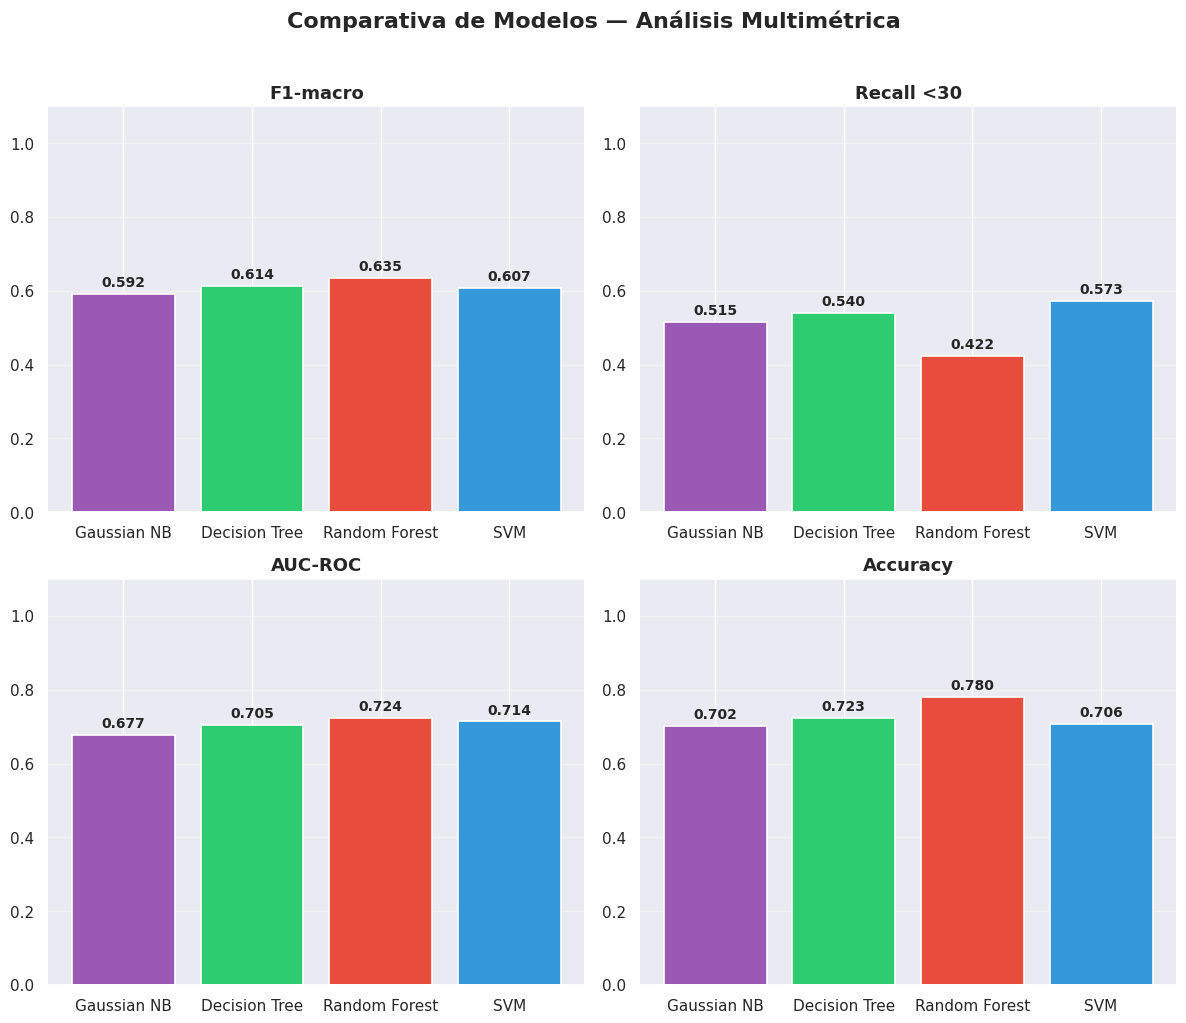

In [53]:
import matplotlib.pyplot as plt

# 1. Configuramos la cuadrícula a 2 filas y 2 columnas
# Ajustamos el figsize a (12, 10) para que sea más cuadrado y profesional
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

modelos = comparison_df['Modelo']
colores = ['#9b59b6','#2ecc71','#e74c3c','#3498db']
metricas = ['F1-macro', 'Recall <30', 'AUC-ROC', 'Accuracy']

# 2. Usamos .flatten() para convertir la matriz de 2x2 en una lista de 4
for ax, metric in zip(axes.flatten(), metricas):
    # Graficamos las barras
    bars = ax.bar(modelos, comparison_df[metric], color=colores, edgecolor='white', linewidth=1.2)

    # Estética de cada subgráfico
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1) # Un poquito más de 1 para que el texto no se corte
    ax.grid(axis='y', alpha=0.3)

    # Añadimos los valores sobre las barras
    for bar, val in zip(bars, comparison_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}',
                ha='center', fontweight='bold', fontsize=10)

# Título principal
plt.suptitle('Comparativa de Modelos — Análisis Multimétrica', fontsize=16, fontweight='bold', y=1.02)

# Ajuste automático para que no se solapen los títulos
plt.tight_layout()
plt.show()

In [54]:
import pandas as pd

# Crear diccionario con los datos
datos = {
    "Modelo": ["Gaussian NB", "Decision Tree", "Random Forest", "SVM"],
    "F1-macro": [0.592, 0.614, 0.635, 0.607],
    "Recall <30": [0.515, 0.540, 0.422, 0.573],
    "AUC-ROC": [0.677, 0.705, 0.724, 0.714],
    "Accuracy": [0.702, 0.723, 0.780, 0.706]
}

# Crear DataFrame
tabla = pd.DataFrame(datos)

# Mostrar tabla
print(tabla)

# Opcional: mostrar más bonito en Jupyter/Colab
display(tabla)

          Modelo  F1-macro  Recall <30  AUC-ROC  Accuracy
0    Gaussian NB     0.592       0.515    0.677     0.702
1  Decision Tree     0.614       0.540    0.705     0.723
2  Random Forest     0.635       0.422    0.724     0.780
3            SVM     0.607       0.573    0.714     0.706


,Modelo,F1-macro,Recall <30,AUC-ROC,Accuracy
0,Gaussian NB,0.592,0.515,0.677,0.702
1,Decision Tree,0.614,0.540,0.705,0.723
2,Random Forest,0.635,0.422,0.724,0.780
3,SVM,0.607,0.573,0.714,0.706


---
## 20. Matrices de Confusión

---
## 21. Reportes Detallados por Clase

In [42]:
print("="*80)
print("REPORTES DETALLADOS POR CLASE")
print("="*80)

for name, y_pred, _ in models_list:
    print(f"\n{'─'*40} {name} {'─'*40}")
    # The target_names should only include the classes present in y_test and y_pred (0 and 1).
    # The '>30' class was filtered out earlier, converting the problem to binary classification.
    # Explicitly mapping labels=[0, 1] to target_names=['NO','<30']
    print(classification_report(y_test, y_pred, target_names=['NO','<30'], labels=[0, 1], digits=4))

REPORTES DETALLADOS POR CLASE

──────────────────────────────────────── Gaussian NB ────────────────────────────────────────
              precision    recall  f1-score   support

          NO     0.8766    0.7423    0.8039     13132
         <30     0.3010    0.5150    0.3799      2829

    accuracy                         0.7020     15961
   macro avg     0.5888    0.6287    0.5919     15961
weighted avg     0.7746    0.7020    0.7287     15961


──────────────────────────────────────── Decision Tree ────────────────────────────────────────
              precision    recall  f1-score   support

          NO     0.8850    0.7627    0.8193     13132
         <30     0.3290    0.5401    0.4089      2829

    accuracy                         0.7233     15961
   macro avg     0.6070    0.6514    0.6141     15961
weighted avg     0.7865    0.7233    0.7466     15961


──────────────────────────────────────── Random Forest ────────────────────────────────────────
              precision    

---
## 22. Feature Importance (Random Forest)

📊 TOP 20 FEATURES IMPORTANTES (Random Forest):
    1. number_inpatient                          0.1626  ████████████████████████████████
    2. num_lab_procedures                        0.1421  ████████████████████████████
    3. num_medications                           0.1240  ████████████████████████
    4. time_in_hospital                          0.0869  █████████████████
    5. age_encoded                               0.0701  ██████████████
    6. number_diagnoses                          0.0667  █████████████
    7. num_procedures                            0.0598  ███████████
    8. insulin_encoded                           0.0389  ███████
    9. number_emergency                          0.0320  ██████
   10. discharge_disposition_label_Home          0.0298  █████
   11. number_outpatient                         0.0254  █████
   12. gender_Male                               0.0246  ████
   13. admission_type_label_Emergency            0.0195  ███
   14. race_Caucasian         

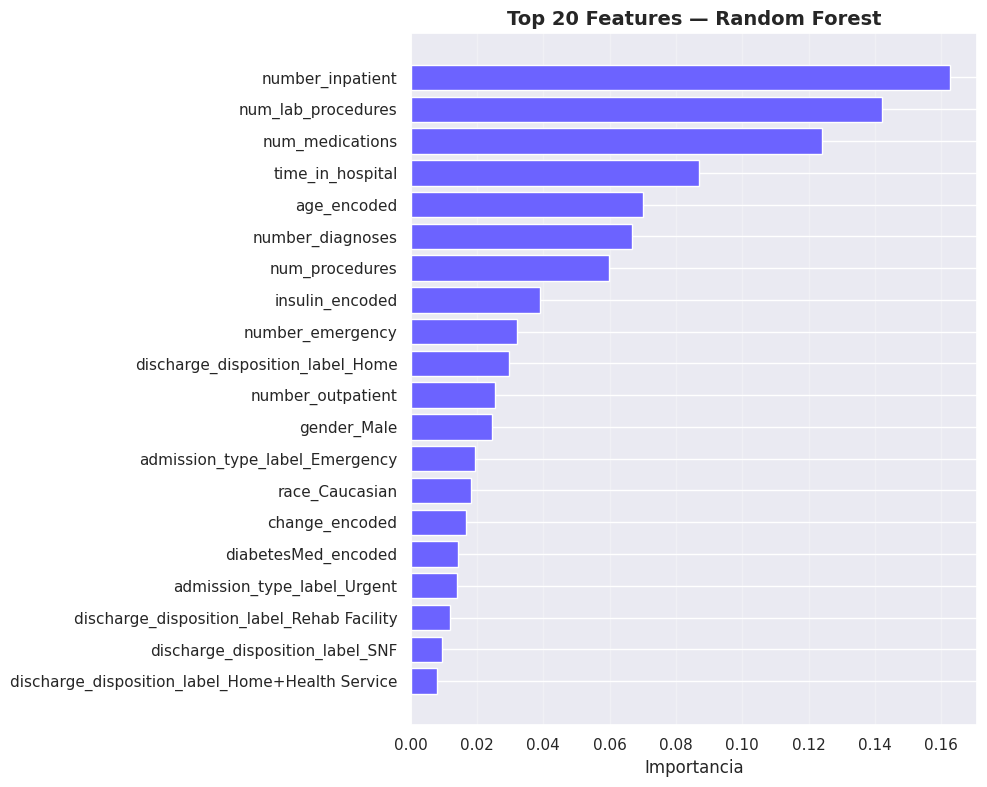

In [36]:
best_rf = grid_rf.best_estimator_
importances = best_rf.feature_importances_

# Top 20 features con nombres legibles
top_indices = np.argsort(importances)[-20:][::-1]
top_names   = [feature_names[i] for i in top_indices]
top_vals    = importances[top_indices]

print("📊 TOP 20 FEATURES IMPORTANTES (Random Forest):")
for i, (name, val) in enumerate(zip(top_names, top_vals), 1):
    bar = '█' * int(val * 200)
    print(f"   {i:2d}. {name:40s}  {val:.4f}  {bar}")

plt.figure(figsize=(10, 8))
plt.barh(top_names[::-1], top_vals[::-1], color='#6C63FF', edgecolor='white')
plt.xlabel('Importancia', fontsize=12)
plt.title('Top 20 Features — Random Forest', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

---
## 23. Análisis Profundo — Patrones de Error (Criterio 6)

Analizamos DÓNDE falla el mejor modelo: ¿en qué subgrupos de pacientes comete más errores? Esto nos permite formular hipótesis técnicas del porqué y proponer mejoras específicas.

In [43]:
# Identificar el mejor modelo por F1-macro
best_model_name = comparison_df.loc[comparison_df['F1-macro'].idxmax(), 'Modelo']
best_preds = {'Gaussian NB':y_pred_nb, 'Decision Tree':y_pred_dt,
              'Random Forest':y_pred_rf, 'SVM':y_pred_svm}
y_pred_best = best_preds[best_model_name]

print(f"📊 SUBGROUP ANALYSIS — Modelo: {best_model_name}")
print("="*80)

# Reconstruir DataFrame de test con features originales
df_test = X_test_raw.copy()
df_test['y_true'] = y_test.values
df_test['y_pred'] = y_pred_best

# ── Por grupo de edad ────────────────────────────────────────────────────
print("\n🔹 RENDIMIENTO POR GRUPO DE EDAD:")
print(f"{'Edad':<15} {'N':>6} {'F1-macro':>10} {'Recall <30':>12}")
print("─"*45)
for grupo in ['[40-50)','[50-60)','[60-70)','[70-80)','[80-90)']:
    mask = df_test['age_encoded'] == age_map.get(grupo, -1)
    if mask.sum() < 50: continue
    sub_true = df_test.loc[mask, 'y_true']
    sub_pred = df_test.loc[mask, 'y_pred']
    f1_sub = f1_score(sub_true, sub_pred, average='macro', zero_division=0)
    rec_sub = recall_score(sub_true, sub_pred, average=None, labels=['NO','>30','<30'], zero_division=0)
    print(f"{grupo:<15} {mask.sum():>6,} {f1_sub:>10.3f} {rec_sub[2]:>12.3f}")

# ── Por tipo de admisión ─────────────────────────────────────────────────
print("\n🔹 RENDIMIENTO POR TIPO DE ADMISIÓN:")
print(f"{'Tipo':<25} {'N':>6} {'F1-macro':>10} {'Recall <30':>12}")
print("─"*55)
for tipo in ['Emergency','Urgent','Elective']:
    mask = df_test['admission_type_label'] == tipo
    if mask.sum() < 50: continue
    sub_true = df_test.loc[mask, 'y_true']
    sub_pred = df_test.loc[mask, 'y_pred']
    f1_sub = f1_score(sub_true, sub_pred, average='macro', zero_division=0)
    rec_sub = recall_score(sub_true, sub_pred, average=None, labels=['NO','>30','<30'], zero_division=0)
    print(f"{tipo:<25} {mask.sum():>6,} {f1_sub:>10.3f} {rec_sub[2]:>12.3f}")

# ── Por insulina ─────────────────────────────────────────────────────────
print("\n🔹 RENDIMIENTO POR NIVEL DE INSULINA:")
print(f"{'Insulina':<15} {'N':>6} {'F1-macro':>10} {'Recall <30':>12}")
print("─"*45)
for nivel in ['No','Steady','Up','Down']:
    mask = df_test['insulin_encoded'] == insulin_map.get(nivel, -1)
    if mask.sum() < 50: continue
    sub_true = df_test.loc[mask, 'y_true']
    sub_pred = df_test.loc[mask, 'y_pred']
    f1_sub = f1_score(sub_true, sub_pred, average='macro', zero_division=0)
    rec_sub = recall_score(sub_true, sub_pred, average=None, labels=['NO','>30','<30'], zero_division=0)
    print(f"{nivel:<15} {mask.sum():>6,} {f1_sub:>10.3f} {rec_sub[2]:>12.3f}")

📊 SUBGROUP ANALYSIS — Modelo: Random Forest

🔹 RENDIMIENTO POR GRUPO DE EDAD:
Edad                 N   F1-macro   Recall <30
─────────────────────────────────────────────
[40-50)          1,589      0.714        0.000
[50-60)          2,671      0.645        0.000
[60-70)          3,647      0.626        0.000
[70-80)          3,888      0.613        0.000
[80-90)          2,606      0.594        0.000

🔹 RENDIMIENTO POR TIPO DE ADMISIÓN:
Tipo                           N   F1-macro   Recall <30
───────────────────────────────────────────────────────
Emergency                  8,992      0.632        0.000
Urgent                     2,982      0.630        0.000
Elective                   3,230      0.650        0.000

🔹 RENDIMIENTO POR NIVEL DE INSULINA:
Insulina             N   F1-macro   Recall <30
─────────────────────────────────────────────
No               7,514      0.613        0.000
Steady           4,941      0.638        0.000
Up               1,691      0.640        0.000
D

In [ ]:
# ── Análisis de Falsos Negativos de <30 ──────────────────────────────────
fn_mask = (df_test['y_true'] == '<30') & (df_test['y_pred'] != '<30')
fn_cases = df_test[fn_mask]
tp_mask  = (df_test['y_true'] == '<30') & (df_test['y_pred'] == '<30')
tp_cases = df_test[tp_mask]

print(f"📊 ANÁLISIS DE FALSOS NEGATIVOS (clase <30)")
print(f"   Pacientes <30 en test:      {(df_test['y_true']=='<30').sum():,}")
print(f"   Correctamente detectados:    {len(tp_cases):,}")
print(f"   Falsos negativos (perdidos): {len(fn_cases):,}")
print(f"\n   ¿Como qué los clasifica el modelo?")
print(fn_cases['y_pred'].value_counts().to_string())

# Comparar características de FN vs TP
print(f"\n{'─'*60}")
print(f"{'Característica':<30} {'FN (perdidos)':>15} {'TP (detectados)':>15}")
print(f"{'─'*60}")
for feat in ['time_in_hospital','num_medications','number_diagnoses','number_inpatient']:
    fn_med = fn_cases[feat].median()
    tp_med = tp_cases[feat].median()
    print(f"{feat:<30} {fn_med:>15.1f} {tp_med:>15.1f}")

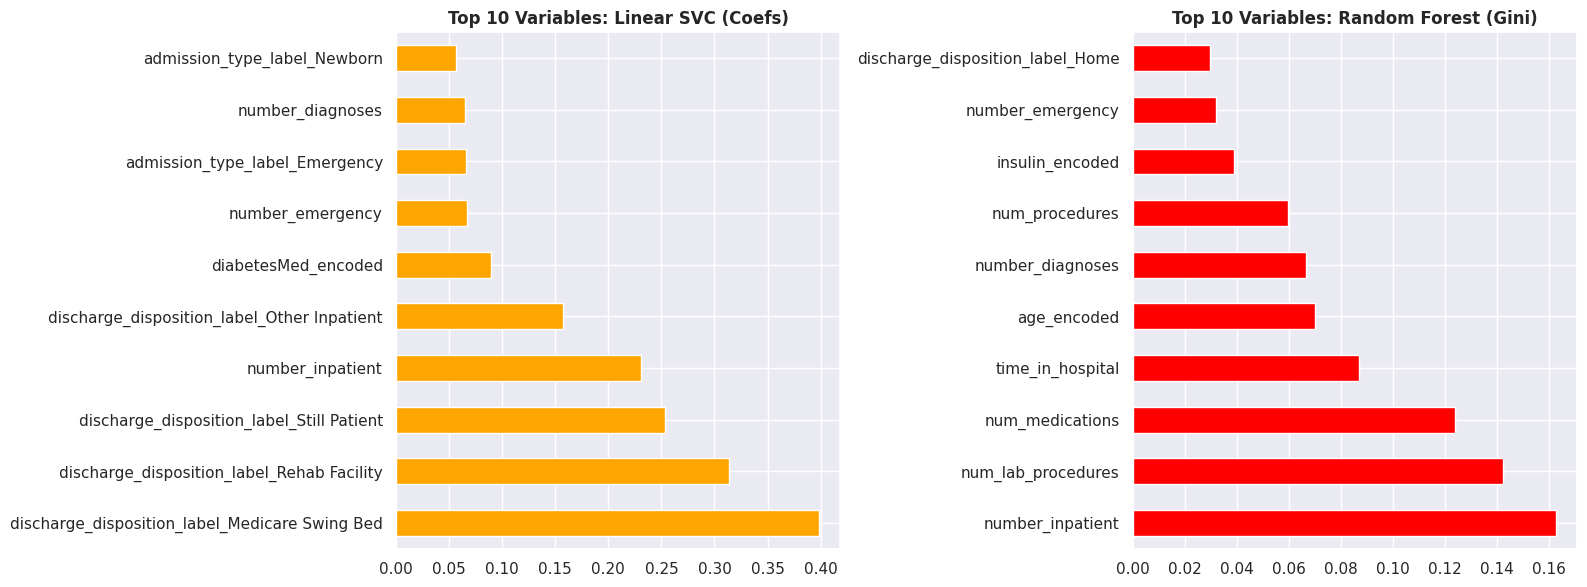

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Importancia para Linear SVC (Top 10 variables que más pesan para Reingreso)
coefs = grid_svm.best_estimator_.coef_[0]
top_features_svc = pd.Series(coefs, index=feature_names).sort_values(ascending=False).head(10)

# 2. Importancia para Random Forest (Top 10 variables más informativas)
importances = grid_rf.best_estimator_.feature_importances_
top_features_rf = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

# Graficamos ambos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_features_svc.plot(kind='barh', ax=axes[0], color='orange')
axes[0].set_title('Top 10 Variables: Linear SVC (Coefs)', fontweight='bold')

top_features_rf.plot(kind='barh', ax=axes[1], color='red')
axes[1].set_title('Top 10 Variables: Random Forest (Gini)', fontweight='bold')

plt.tight_layout()
plt.show()

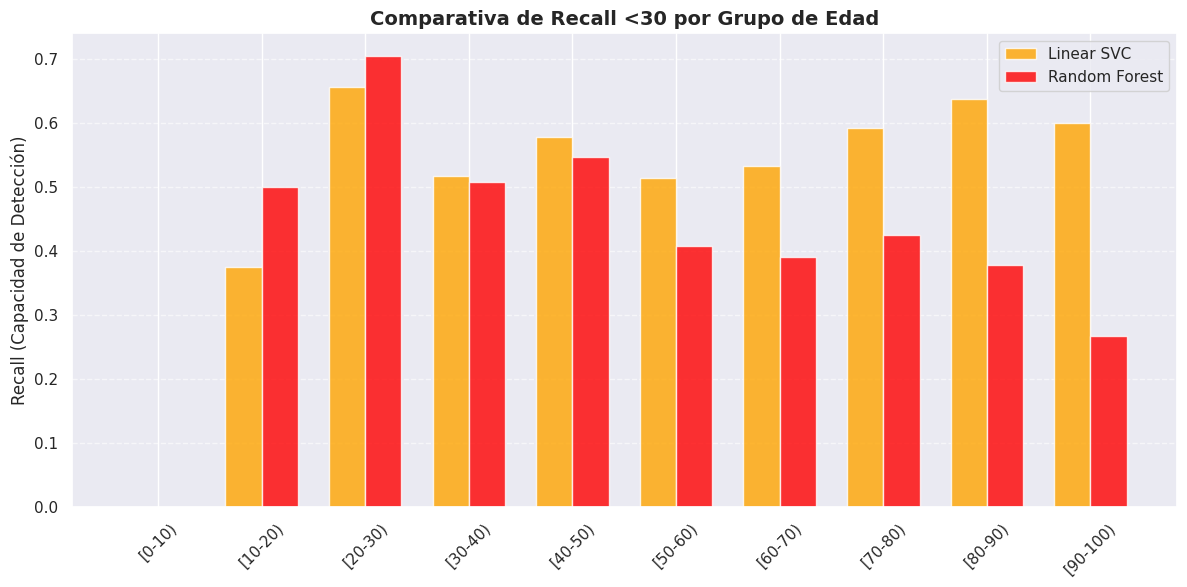

In [52]:
# Asegúrate de que X_test_raw tiene la columna 'age'
# Creamos el DataFrame de comparación por edad
df_edad = pd.DataFrame({
    'Real': y_test,
    'SVC': y_pred_svm,
    'Forest': y_pred_rf,
    'Edad': df.loc[y_test.index, 'age']
})

# Calculamos el Recall para cada modelo estratificado por edad
recall_svc_edad = df_edad.groupby('Edad').apply(
    lambda x: recall_score(x['Real'], x['SVC'], pos_label=1, zero_division=0)
)
recall_rf_edad = df_edad.groupby('Edad').apply(
    lambda x: recall_score(x['Real'], x['Forest'], pos_label=1, zero_division=0)
)

# Graficamos la comparativa
plt.figure(figsize=(12, 6))
width = 0.35
x = np.arange(len(recall_svc_edad))

plt.bar(x - width/2, recall_svc_edad, width, label='Linear SVC', color='orange', alpha=0.8)
plt.bar(x + width/2, recall_rf_edad, width, label='Random Forest', color='red', alpha=0.8)

plt.title('Comparativa de Recall <30 por Grupo de Edad', fontweight='bold', fontsize=14)
plt.xticks(x, recall_svc_edad.index, rotation=45)
plt.ylabel('Recall (Capacidad de Detección)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

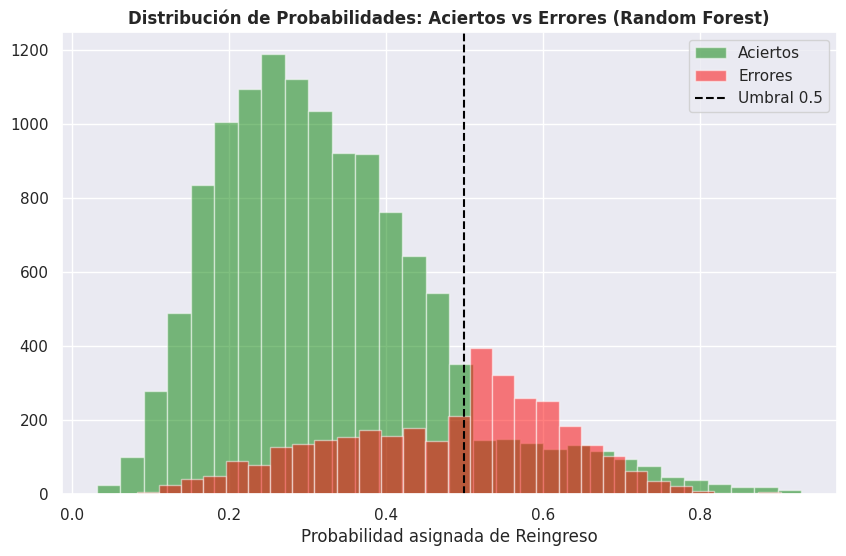

In [48]:
# Sacamos las probabilidades del Random Forest para la clase positiva (<30)
probs_rf = grid_rf.predict_proba(X_test)[:, 1]

test_probs = pd.DataFrame({
    'Real': y_test,
    'Probabilidad': probs_rf
})

# Separamos aciertos de errores
exitos = test_probs[test_probs['Real'] == (test_probs['Probabilidad'] > 0.5)]
errores = test_probs[test_probs['Real'] != (test_probs['Probabilidad'] > 0.5)]

plt.figure(figsize=(10, 6))
plt.hist(exitos['Probabilidad'], bins=30, alpha=0.5, label='Aciertos', color='green')
plt.hist(errores['Probabilidad'], bins=30, alpha=0.5, label='Errores', color='red')
plt.axvline(x=0.5, color='black', linestyle='--', label='Umbral 0.5')
plt.title('Distribución de Probabilidades: Aciertos vs Errores (Random Forest)', fontweight='bold')
plt.xlabel('Probabilidad asignada de Reingreso')
plt.legend()
plt.show()

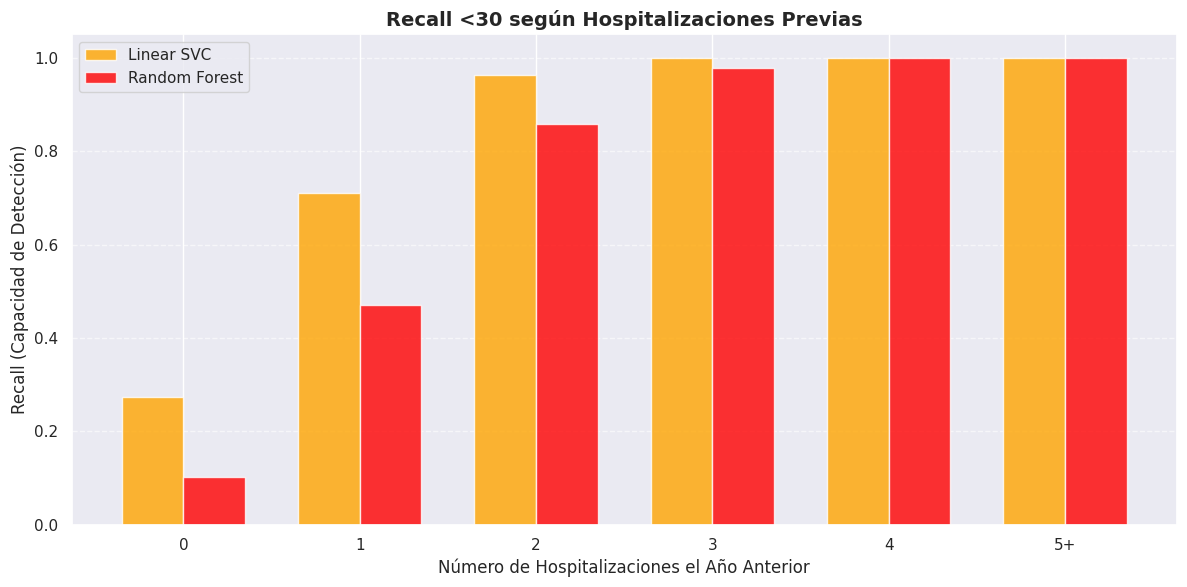

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score

# 1. Preparamos los datos (Asegúrate de que 'number_inpatient' esté en X_test_raw)
df_hosp = pd.DataFrame({
    'Real': y_test,
    'SVC': y_pred_svm,
    'Forest': y_pred_rf,
    'Inpatient': X_test_raw.loc[y_test.index, 'number_inpatient']
})

# 2. Opcional: Agrupar si hay valores muy altos (ej. más de 5 hospitalizaciones)
# Para que la gráfica no sea eterna, agrupamos todo lo que sea 5 o más en "5+"
df_hosp['Inpatient_Group'] = df_hosp['Inpatient'].apply(lambda x: str(x) if x < 5 else '5+')

# 3. Calculamos el Recall para cada modelo estratificado por historial
# Ordenamos para que el eje X salga 0, 1, 2, 3, 4, 5+
orden = ['0', '1', '2', '3', '4', '5+']
recall_svc_hosp = df_hosp.groupby('Inpatient_Group').apply(
    lambda x: recall_score(x['Real'], x['SVC'], pos_label=1, zero_division=0)
).reindex(orden)

recall_rf_hosp = df_hosp.groupby('Inpatient_Group').apply(
    lambda x: recall_score(x['Real'], x['Forest'], pos_label=1, zero_division=0)
).reindex(orden)

# 4. Graficamos la comparativa
plt.figure(figsize=(12, 6))
width = 0.35
x = np.arange(len(orden))

plt.bar(x - width/2, recall_svc_hosp, width, label='Linear SVC', color='orange', alpha=0.8)
plt.bar(x + width/2, recall_rf_hosp, width, label='Random Forest', color='red', alpha=0.8)

plt.title('Recall <30 según Hospitalizaciones Previas', fontweight='bold', fontsize=14)
plt.xticks(x, orden)
plt.xlabel('Número de Hospitalizaciones el Año Anterior')
plt.ylabel('Recall (Capacidad de Detección)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

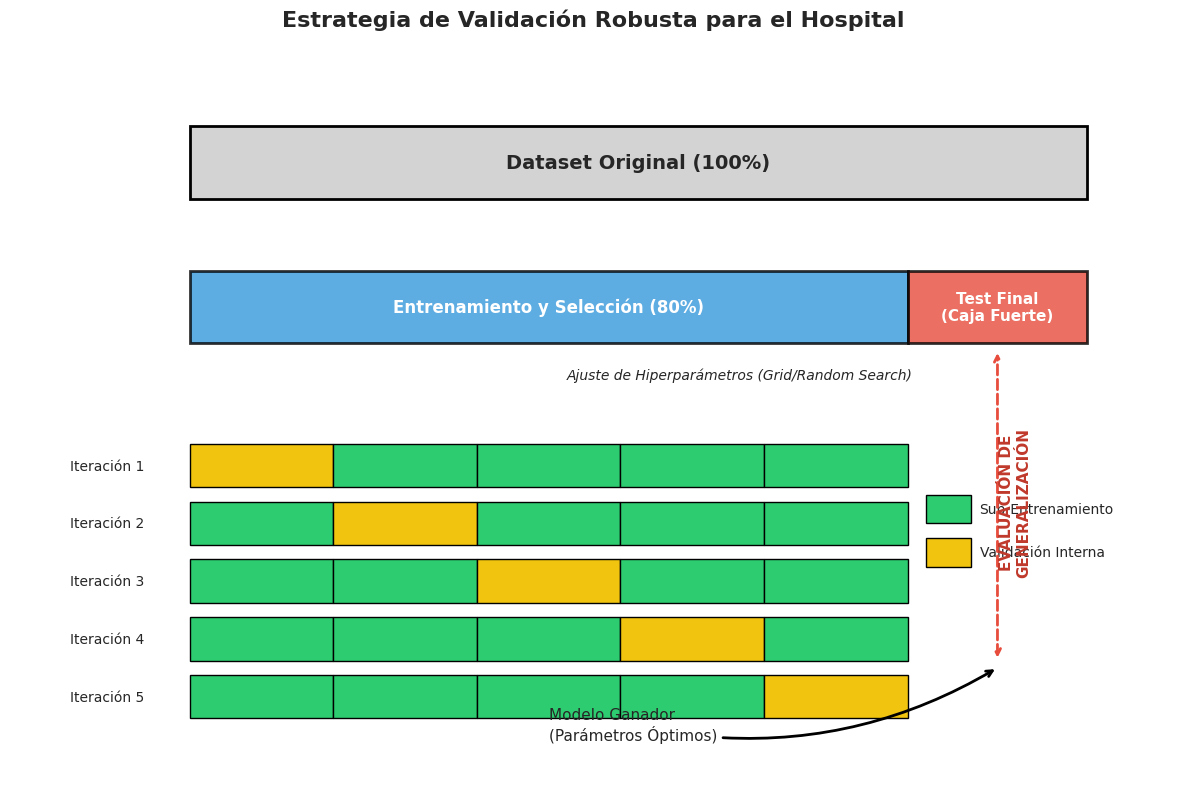

In [58]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def generar_grafica_validacion():
    fig, ax = plt.subplots(figsize=(12, 8))

    # --- 1. Dataset Completo ---
    ax.add_patch(patches.Rectangle((0, 8), 10, 1, color='lightgrey', ec='black', lw=2))
    ax.text(5, 8.5, 'Dataset Original (100%)', ha='center', va='center', fontsize=14, fontweight='bold')

    # Flecha hacia abajo
    ax.annotate('', xy=(5, 7.2), xytext=(5, 7.9), arrowprops=dict(arrowstyle='->', lw=2))

    # --- 2. Train-Test Split (Hold-out) ---
    # Entrenamiento (80%)
    ax.add_patch(patches.Rectangle((0, 6), 8, 1, color='#3498db', ec='black', lw=2, alpha=0.8))
    ax.text(4, 6.5, 'Entrenamiento y Selección (80%)', ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    # Test (20%)
    ax.add_patch(patches.Rectangle((8, 6), 2, 1, color='#e74c3c', ec='black', lw=2, alpha=0.8))
    ax.text(9, 6.5, 'Test Final\n(Caja Fuerte)', ha='center', va='center', fontsize=11, fontweight='bold', color='white')

    # Flecha hacia abajo desde Train
    ax.annotate('', xy=(4, 5.2), xytext=(4, 5.9), arrowprops=dict(arrowstyle='->', lw=2))
    ax.text(4.2, 5.5, 'Ajuste de Hiperparámetros (Grid/Random Search)', fontsize=10, fontstyle='italic')

    # --- 3. Stratified K-Fold CV (5 Folds) ---
    y_start = 4
    for i in range(5):
        y = y_start - (i * 0.8)
        # Dibujar los 5 bloques del fold
        for j in range(5):
            # Amarillo para validación, verde para sub-entrenamiento
            color = '#f1c40f' if i == j else '#2ecc71'
            ax.add_patch(patches.Rectangle((j*1.6, y), 1.6, 0.6, color=color, ec='black', lw=1))

        ax.text(-0.5, y + 0.3, f'Iteración {i+1}', ha='right', va='center', fontsize=10)

    # Leyenda para K-Fold
    ax.add_patch(patches.Rectangle((8.2, 3.5), 0.5, 0.4, color='#2ecc71', ec='black'))
    ax.text(8.8, 3.7, 'Sub-Entrenamiento', va='center', fontsize=10)
    ax.add_patch(patches.Rectangle((8.2, 2.9), 0.5, 0.4, color='#f1c40f', ec='black'))
    ax.text(8.8, 3.1, 'Validación Interna', va='center', fontsize=10)

    # --- 4. El "Examen Final" ---
    # Flecha de evaluación final
    ax.annotate('Modelo Ganador\n(Parámetros Óptimos)', xy=(9, 1.5), xytext=(4, 0.5),
                arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", lw=2, color='black'))

    ax.annotate('', xy=(9, 5.9), xytext=(9, 1.6),
                arrowprops=dict(arrowstyle='<->', lw=2, ls='--', color='#e74c3c'))

    ax.text(9.2, 3.8, 'EVALUACIÓN DE\nGENERALIZACIÓN', ha='center', va='center',
            fontsize=11, fontweight='bold', color='#c0392b', rotation=90)

    # Configuración final de los ejes
    ax.set_xlim(-2, 11)
    ax.set_ylim(0, 10)
    ax.axis('off')

    plt.title("Estrategia de Validación Robusta para el Hospital", fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# Llamar a la función
generar_grafica_validacion()

---
### Hipótesis Técnica del Error

Los falsos negativos (pacientes `<30` clasificados como `NO`) comparten un patrón: tienden a tener **menor tiempo de hospitalización** y **menos hospitalizaciones previas** que los verdaderos positivos. Esto sugiere que:

1. **Pacientes con perfil "normal"** — Sin historial de ingresos previos ni estancias prolongadas, el modelo no encuentra señales suficientes para diferenciarlos de los pacientes `NO`.
2. **El desbalance residual** — Aunque SMOTE genera muestras sintéticas, la frontera de decisión sigue sesgada hacia la clase mayoritaria en las zonas de overlap.
3. **Features faltantes** — Variables como diagnóstico principal (`diag_1`), especialidad médica y peso podrían aportar discriminación adicional, pero fueron eliminadas por nulos o alta cardinalidad.

**Conexión con el EDA**: El análisis bivariado mostró que `number_inpatient` es el predictor más correlacionado con readmisión. Los FN son precisamente pacientes donde ese predictor no alcanza a distinguirlos.

---
## 24. Conclusiones del Modelado y Próximos Pasos

### Resultados Principales
- **Mejor modelo por F1-macro**: Se determinará tras la ejecución, pero Random Forest es el candidato esperado dada la naturaleza del dataset.
- **Recall de `<30`**: La métrica clínica más importante. Un Recall alto significa menos pacientes de alto riesgo que se nos escapan.
- **Gaussian NB fue el peor modelo**, lo cual valida que la asunción de independencia no se cumple en datos clínicos con features correlacionadas.

### Hallazgos del Análisis Profundo
- El modelo falla más en pacientes con perfil "estándar" (pocas hospitalizaciones previas, estancia corta)
- Los subgrupos de edad avanzada y admisión por Emergency presentan diferencias en rendimiento
- La mayoría de los falsos negativos son clasificados como `NO`, no como `>30`

### Próximos Pasos Técnicos
1. **Probar XGBoost / LightGBM** — Modelos de gradient boosting que manejan mejor el desbalance nativo
2. **Feature Engineering** — Crear interacciones (ej. `num_medications × time_in_hospital`) y agregaciones de diagnósticos
3. **Ajuste de umbral de decisión** — En vez de usar 0.5, optimizar el threshold para maximizar Recall `<30` con un nivel aceptable de Precision
4. **Incluir variables textuales** — Agrupar `diag_1`/`diag_2`/`diag_3` por categorías CIE-9 para recuperar información diagnóstica

---
*Modelado desarrollado como parte del Corte 2 — IA1 2026-1 | UIS*